# DataCo Smart Supply Chain Analytics

- **Domain:** Supply Chain & Business Analytics
- **Project Theme:** DataCo Smart Supply Chain Performance Analysis
- **Tools:** Python, Pandas, NumPy, Matplotlib, Seaborn, Plotly, MySQL, Power BI
- **Prepared By:** Hariom Dubey
---

## 1. Project Overview

DataCo Smart Supply Chain Analytics is an end-to-end analytics project built on DataCo Global's order-level transactional data (2015–2018), covering sales, profitability, customers, products, markets, and shipping/delivery performance across 164 countries.

The project is implemented across four tools, each with a distinct role:

| Tool | Role |
|---|---|
| **Excel** | Initial data staging / quick checks |
| **Python** | Data cleaning, exploratory & statistical analysis, insight discovery |
| **SQL** | Structured querying and metric validation |
| **Power BI** | Interactive dashboarding, KPI monitoring, business presentation |

**This notebook covers only the Python component.** Its job is to clean the raw order-item-level dataset, engineer analytical features, and systematically answer the business questions below — producing insights and recommendations that are directly usable by supply chain, sales, and logistics stakeholders. Dashboard design and interactivity are handled separately in Power BI, not here.


## 2. Business Problem

DataCo Global operates across five global markets and ships thousands of orders per month. Two business-critical questions sit at the center of this analysis:

1. **Where is the business making (and losing) money?** — across products, categories, customer segments, and markets.
2. **Why are more than half of all orders at risk of late delivery**, and which markets, categories, or shipping modes are driving that risk?

Without a structured, data-driven view of these two questions, decisions on inventory, pricing, market investment, and logistics partners are made on intuition rather than evidence. This analysis exists to close that gap.


## 3. Business Objectives

- Quantify overall sales, profit, and order volume performance.
- Identify which products, categories, customer segments, and markets drive the most revenue and profit — and where sales volume does **not** translate into profit.
- Measure customer retention and revenue concentration (Pareto effect).
- Evaluate shipping-mode usage and its relationship with delivery performance.
- Quantify late-delivery risk and isolate the markets, categories, and shipping modes most exposed to it.
- Translate all of the above into concrete, actionable business recommendations.


## 4. Key Business Questions

**Performance & Profitability**
1. What are the overall sales, profit, orders, and quantity sold?
2. What is the overall profit margin?
3. How are sales and profit changing over time?
4. Which product categories generate the highest sales, and which generate the highest profit?
5. Which individual products are the top performers?
6. Which products/categories have high sales but comparatively low profitability?

**Customers**
7. Which customer segment contributes the most revenue?
8. How many customers are repeat customers, and what share of revenue do they generate?

**Markets & Geography**
9. Which markets and countries generate the highest sales and profit?
10. Which markets have the highest profit margin, and which need attention?

**Shipping & Delivery**
11. Which shipping modes are most frequently used, and what is the average shipping duration?
12. What percentage of orders are at late-delivery risk?
13. Which markets, categories, and shipping modes carry the highest delivery risk?

**Operational**
14. Are high-volume categories also highly profitable, or is volume masking weak margins?
15. Is there a relationship between sales concentration and delivery risk that could affect customer experience in the business's most important markets?


## 5. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
import os
import warnings

warnings.filterwarnings("ignore")

# Global plotting style
sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 100
plt.rcParams["axes.titlesize"] = 13
plt.rcParams["axes.titleweight"] = "bold"
plt.rcParams["axes.labelsize"] = 11

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 160)

### Brand / semantic color palette (kept consistent across every chart)
COLOR_PRIMARY   = "#7E57C2"   # Primary purple  — sales / primary analytics
COLOR_SECONDARY = "#9575CD"   # Secondary purple — secondary metrics
COLOR_DARK      = "#241354"   # Dark purple      — emphasis / headline bars
COLOR_POSITIVE  = "#2E9D6F"   # Green            — profit / positive outcomes
COLOR_NEGATIVE  = "#D64545"   # Red              — late delivery / risk
COLOR_HIGHLIGHT = "#F59E0B"   # Amber            — highlighted / call-out values
COLOR_NEUTRAL   = "#746A7F"   # Neutral purple-gray — secondary/context series

# A purple-led sequential palette for multi-category bar/line charts
PALETTE = sns.color_palette(
    [COLOR_DARK, COLOR_PRIMARY, COLOR_SECONDARY, "#B39DDB", "#D1C4E9",
     COLOR_HIGHLIGHT, COLOR_POSITIVE, COLOR_NEUTRAL, "#5E35B1", "#4A148C"]
)

# Discrete palette plotly can reuse for consistent qualitative charts
PLOTLY_QUALITATIVE = [COLOR_PRIMARY, COLOR_POSITIVE, COLOR_HIGHLIGHT, COLOR_NEGATIVE,
                       COLOR_SECONDARY, COLOR_DARK, COLOR_NEUTRAL]


def money_fmt(x, pos=None):
    """Format large numbers as $36.78M / $756K style labels for chart axes."""
    if abs(x) >= 1e6:
        return f"${x/1e6:,.2f}M"
    if abs(x) >= 1e3:
        return f"${x/1e3:,.0f}K"
    return f"${x:,.0f}"


def money_label(x):
    """Formatter for printed text / tables.

    Uses the same M/K abbreviation as the axis formatter for large numbers, but
    keeps two decimal places for sub-$1,000 values so metrics such as Average
    Order Value are not silently rounded (e.g. $559.45, not $559).
    """
    if abs(x) >= 1e6:
        return f"${x/1e6:,.2f}M"
    if abs(x) >= 1e3:
        return f"${x/1e3:,.1f}K"
    return f"${x:,.2f}"


## 6. Load Dataset

The raw file uses a non-UTF-8 (Latin-1) encoding — common for this dataset because of accented characters in international customer/city names. We inspect the working directory first, then load accordingly.


In [2]:
# Locate the dataset file in the working environment
candidates = [f for f in os.listdir(".") if f.lower().endswith(".csv") and "dataco" in f.lower()]
print("CSV files found in working directory:", candidates)

DATA_PATH = candidates[0] if candidates else "DataCoSupplyChainDataset.csv"
df = pd.read_csv(DATA_PATH, encoding="latin1")

print(f"\nLoaded '{DATA_PATH}' — shape: {df.shape[0]:,} rows x {df.shape[1]} columns")


CSV files found in working directory: ['DataCoSupplyChainDataset.csv']

Loaded 'DataCoSupplyChainDataset.csv' — shape: 180,519 rows x 53 columns



Loaded 'DataCoSupplyChainDataset.csv' — shape: 180,519 rows x 53 columns


**Note on sensitive fields:** the raw file includes customer-identifying columns (`Customer Email`, `Customer Password`, `Customer Fname`/`Lname`, `Customer Street`, `Customer Zipcode`). The `Email` and `Password` fields are already masked with placeholder values (`XXXXXXXXX`) in the source export, but the name and street fields contain real-looking personal data. To keep this portfolio notebook's outputs safe to publish, all row-level previews below show a **safe analytical subset of columns only** — sensitive identity/address fields are never printed in full. This is a display precaution, not a claim that the underlying dataset is anonymized.


In [3]:
SENSITIVE_COLS = ["Customer Email", "Customer Password", "Customer Fname", "Customer Lname",
                   "Customer Street", "Customer Zipcode"]

SAFE_PREVIEW_COLS = [
    "Order Id", "Customer Id", "order date (DateOrders)", "Product Name", "Category Name",
    "Customer Segment", "Market", "Order Country", "Sales", "Profit",
    "Shipping Mode", "Delivery Status",
]
# 'Profit' doesn't exist yet at this stage (created during cleaning) — use the raw equivalent for now
raw_preview_cols = [c if c != "Profit" else "Benefit per order" for c in SAFE_PREVIEW_COLS]

df[raw_preview_cols].head()

,Order Id,Customer Id,order date (DateOrders),Product Name,Category Name,Customer Segment,Market,Order Country,Sales,Benefit per order,Shipping Mode,Delivery Status
0,77202,20755,1/31/2018 22:56,Smart watch,Sporting Goods,Consumer,Pacific Asia,Indonesia,327.75,91.250000,Standard Class,Advance shipping
1,75939,19492,1/13/2018 12:27,Smart watch,Sporting Goods,Consumer,Pacific Asia,India,327.75,-249.089996,Standard Class,Late delivery
2,75938,19491,1/13/2018 12:06,Smart watch,Sporting Goods,Consumer,Pacific Asia,India,327.75,-247.779999,Standard Class,Shipping on time
3,75937,19490,1/13/2018 11:45,Smart watch,Sporting Goods,Home Office,Pacific Asia,Australia,327.75,22.860001,Standard Class,Advance shipping
4,75936,19489,1/13/2018 11:24,Smart watch,Sporting Goods,Corporate,Pacific Asia,Australia,327.75,134.210007,Standard Class,Advance shipping


In [4]:
df[raw_preview_cols].tail()

,Order Id,Customer Id,order date (DateOrders),Product Name,Category Name,Customer Segment,Market,Order Country,Sales,Benefit per order,Shipping Mode,Delivery Status
180514,26043,1005,1/16/2016 3:40,Field & Stream Sportsman 16 Gun Fire Safe,Fishing,Home Office,Pacific Asia,China,399.980011,40.000000,Standard Class,Shipping on time
180515,26037,9141,1/16/2016 1:34,Field & Stream Sportsman 16 Gun Fire Safe,Fishing,Corporate,Pacific Asia,Japón,399.980011,-613.770019,Second Class,Late delivery
180516,26024,291,1/15/2016 21:00,Field & Stream Sportsman 16 Gun Fire Safe,Fishing,Corporate,Pacific Asia,Australia,399.980011,141.110001,Standard Class,Late delivery
180517,26022,2813,1/15/2016 20:18,Field & Stream Sportsman 16 Gun Fire Safe,Fishing,Consumer,Pacific Asia,Australia,399.980011,186.229996,Standard Class,Advance shipping
180518,26018,7547,1/15/2016 18:54,Field & Stream Sportsman 16 Gun Fire Safe,Fishing,Consumer,Pacific Asia,India,399.980011,168.949997,Standard Class,Shipping on time


In [5]:
print("Shape:", df.shape)
print("\nColumn names:")
for c in df.columns:
    print(" -", c)


Shape: (180519, 53)

Column names:
 - Type
 - Days for shipping (real)
 - Days for shipment (scheduled)
 - Benefit per order
 - Sales per customer
 - Delivery Status
 - Late_delivery_risk
 - Category Id
 - Category Name
 - Customer City
 - Customer Country
 - Customer Email
 - Customer Fname
 - Customer Id
 - Customer Lname
 - Customer Password
 - Customer Segment
 - Customer State
 - Customer Street
 - Customer Zipcode
 - Department Id
 - Department Name
 - Latitude
 - Longitude
 - Market
 - Order City
 - Order Country
 - Order Customer Id
 - order date (DateOrders)
 - Order Id
 - Order Item Cardprod Id
 - Order Item Discount
 - Order Item Discount Rate
 - Order Item Id
 - Order Item Product Price
 - Order Item Profit Ratio
 - Order Item Quantity
 - Sales
 - Order Item Total
 - Order Profit Per Order
 - Order Region
 - Order State
 - Order Status
 - Order Zipcode
 - Product Card Id
 - Product Category Id
 - Product Description
 - Product Image
 - Product Name
 - Product Price
 - Produ

In [6]:
df.dtypes.to_frame(name="Data Type")

,Data Type
Type,object
Days for shipping (real),int64
Days for shipment (scheduled),int64
Benefit per order,float64
Sales per customer,float64
Delivery Status,object
Late_delivery_risk,int64
Category Id,int64
Category Name,object
Customer City,object


## 7. Dataset Overview

The dataset is **order-item level**: each row represents one product line item within an order, not one order. An order with 3 different products will appear as 3 rows sharing the same `Order Id`. This distinction drives every aggregation decision later in the notebook (distinct `Order Id` for order counts, distinct `Customer Id` for customer counts, distinct `Product Card Id` for product counts).


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 180519 entries, 0 to 180518
Data columns (total 53 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   Type                           180519 non-null  object 
 1   Days for shipping (real)       180519 non-null  int64  
 2   Days for shipment (scheduled)  180519 non-null  int64  
 3   Benefit per order              180519 non-null  float64
 4   Sales per customer             180519 non-null  float64
 5   Delivery Status                180519 non-null  object 
 6   Late_delivery_risk             180519 non-null  int64  
 7   Category Id                    180519 non-null  int64  
 8   Category Name                  180519 non-null  object 
 9   Customer City                  180519 non-null  object 
 10  Customer Country               180519 non-null  object 
 11  Customer Email                 180519 non-null  object 
 12  Customer Fname                

In [8]:
# describe() is restricted to non-sensitive columns so that customer names,
# street addresses and zipcodes are never rendered in notebook output.
describe_cols = [c for c in df.columns if c not in SENSITIVE_COLS]
df[describe_cols].describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Type,180519,4,DEBIT,69295,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Days for shipping (real),180519.0,NaN,NaN,NaN,3.497654,1.623722,0.0,2.0,3.0,5.0,6.0
Days for shipment (scheduled),180519.0,NaN,NaN,NaN,2.931847,1.374449,0.0,2.0,4.0,4.0,4.0
Benefit per order,180519.0,NaN,NaN,NaN,21.974989,104.433526,-4274.97998,7.0,31.52,64.800003,911.799988
Sales per customer,180519.0,NaN,NaN,NaN,183.107609,120.04367,7.49,104.379997,163.990005,247.399994,1939.98999
Delivery Status,180519,4,Late delivery,98977,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Late_delivery_risk,180519.0,NaN,NaN,NaN,0.548291,0.497664,0.0,0.0,1.0,1.0,1.0
Category Id,180519.0,NaN,NaN,NaN,31.851451,15.640064,2.0,18.0,29.0,45.0,76.0
Category Name,180519,50,Cleats,24551,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Customer City,180519,563,Caguas,66770,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [9]:
# Classify columns by role to understand the schema before analysis
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = df.select_dtypes(include=["object"]).columns.tolist()
date_like_cols = [c for c in df.columns if "date" in c.lower()]

print(f"Numeric columns ({len(numeric_cols)}):\n{numeric_cols}\n")
print(f"Categorical columns ({len(categorical_cols)}):\n{categorical_cols}\n")
print(f"Date-like columns ({len(date_like_cols)}):\n{date_like_cols}")


Numeric columns (29):
['Days for shipping (real)', 'Days for shipment (scheduled)', 'Benefit per order', 'Sales per customer', 'Late_delivery_risk', 'Category Id', 'Customer Id', 'Customer Zipcode', 'Department Id', 'Latitude', 'Longitude', 'Order Customer Id', 'Order Id', 'Order Item Cardprod Id', 'Order Item Discount', 'Order Item Discount Rate', 'Order Item Id', 'Order Item Product Price', 'Order Item Profit Ratio', 'Order Item Quantity', 'Sales', 'Order Item Total', 'Order Profit Per Order', 'Order Zipcode', 'Product Card Id', 'Product Category Id', 'Product Description', 'Product Price', 'Product Status']

Categorical columns (24):
['Type', 'Delivery Status', 'Category Name', 'Customer City', 'Customer Country', 'Customer Email', 'Customer Fname', 'Customer Lname', 'Customer Password', 'Customer Segment', 'Customer State', 'Customer Street', 'Department Name', 'Market', 'Order City', 'Order Country', 'order date (DateOrders)', 'Order Region', 'Order State', 'Order Status', 'Produc

**Data dictionary — key business fields** (definitions inferred from column names and validated against the actual data):

| Field | Business Meaning |
|---|---|
| `Order Id` | Unique order identifier; one order can span multiple rows (line items) |
| `Order Item Id` | Unique identifier for each order line item — one row = one `Order Item Id` |
| `Customer Id` / `Order Customer Id` | Unique customer identifier (identical fields, confirmed below) |
| `Sales` | Line-item revenue = `Order Item Product Price` × `Order Item Quantity` (confirmed below) |
| `Order Item Total` | Line-item revenue **after** discount is applied |
| `Order Item Discount` / `Discount Rate` | Discount amount / rate applied to the line item |
| `Benefit per order` / `Order Profit Per Order` | Line-item profit (identical fields, confirmed below) |
| `Order Item Profit Ratio` | Profit ÷ Sales at line-item level |
| `Category Name` / `Category Id` | Product category |
| `Market` | Highest-level geographic grouping (5 values: LATAM, Europe, Pacific Asia, USCA, Africa) |
| `Order Region` | Sub-region within a market (e.g. Western Europe, Central America) |
| `Order Country` / `Order State` / `Order City` | Shipping destination geography |
| `Customer Segment` | Consumer / Corporate / Home Office |
| `Shipping Mode` | Standard Class / Second Class / First Class / Same Day |
| `Days for shipping (real)` | Actual days taken to ship |
| `Days for shipment (scheduled)` | Days originally scheduled/promised |
| `Delivery Status` | Late delivery / Advance shipping / Shipping on time / Shipping canceled |
| `Late_delivery_risk` | Binary flag (1 = late) |
| `Order Status` | Order lifecycle status (COMPLETE, PENDING, CANCELED, SUSPECTED_FRAUD, etc.) |

We validate several of these relationships directly in the next cell rather than assuming them.


In [10]:
# Validate assumed field relationships instead of guessing from names
checks = {
    "Sales == Price x Quantity": np.allclose(df["Order Item Product Price"] * df["Order Item Quantity"], df["Sales"], atol=1e-2),
    "Customer Id == Order Customer Id": (df["Customer Id"] == df["Order Customer Id"]).all(),
    "Category Id == Product Category Id": (df["Category Id"] == df["Product Category Id"]).all(),
    "Product Card Id == Order Item Cardprod Id": (df["Product Card Id"] == df["Order Item Cardprod Id"]).all(),
    "Benefit per order == Order Profit Per Order": np.allclose(df["Benefit per order"], df["Order Profit Per Order"], atol=1e-2),
}
for k, v in checks.items():
    print(f"{k}: {v}")


Sales == Price x Quantity: True
Customer Id == Order Customer Id: True
Category Id == Product Category Id: True
Product Card Id == Order Item Cardprod Id: True
Benefit per order == Order Profit Per Order: True


**Result:** all five assumed relationships hold true across the full dataset. This means several column pairs are exact duplicates (`Customer Id`/`Order Customer Id`, `Category Id`/`Product Category Id`, `Product Card Id`/`Order Item Cardprod Id`, `Benefit per order`/`Order Profit Per Order`). We keep one representative of each pair going forward to avoid redundant analysis.


## 8. Data Quality Assessment

We check completeness, duplication, referential consistency, and value validity before doing any cleaning.


In [11]:
# Missing values summary
missing = df.isnull().sum()
missing = missing[missing > 0]
missing_df = pd.DataFrame({
    "Column": missing.index,
    "Missing Count": missing.values,
    "Missing %": (missing.values / len(df) * 100).round(2),
    "Data Type": [df[c].dtype for c in missing.index],
}).sort_values("Missing Count", ascending=False).reset_index(drop=True)

missing_df


,Column,Missing Count,Missing %,Data Type
0,Product Description,180519,100.00,float64
1,Order Zipcode,155679,86.24,float64
2,Customer Lname,8,0.00,object
3,Customer Zipcode,3,0.00,float64


**Interpretation:**
- `Product Description` is missing in **100% of rows** — the field was never populated in this export and carries no analytical value; it will be dropped.
- `Order Zipcode` is missing in ~86% of rows — this is expected, since most orders ship internationally and zipcodes are primarily a US/Canada concept. It will be kept but not used as a primary analysis field.
- `Customer Lname` and `Customer Zipcode` are missing in only a handful of rows (8 and 3) — negligible and left as-is; these fields aren't used in any aggregation.


In [12]:
# Duplicate rows (exact full-row duplicates)
full_dupes = df.duplicated().sum()
print(f"Exact duplicate rows: {full_dupes}")

# Duplicate Order Item Id (should be zero — one row per line item)
print(f"Duplicate Order Item Id: {df['Order Item Id'].duplicated().sum()}")

# Repeated Order Id (EXPECTED — multiple products per order)
repeated_order_ids = df['Order Id'].duplicated().sum()
print(f"Rows sharing an Order Id with another row: {repeated_order_ids:,} "
      f"({repeated_order_ids/len(df)*100:.1f}% of rows)")


Exact duplicate rows: 0
Duplicate Order Item Id: 0
Rows sharing an Order Id with another row: 114,767 (63.6% of rows)


**Duplicate rows vs. repeated Order IDs — important distinction:**

There are **zero exact duplicate rows** and **zero duplicate `Order Item Id`s**, meaning every row is a genuinely unique line item — no accidental data duplication.

However, **`Order Id` repeats across ~64% of rows.** This is *expected and correct*: this is an order-item level dataset, so an order containing 3 products produces 3 rows with the same `Order Id`. We must **not** deduplicate on `Order Id` — doing so would silently discard real line items and understate sales, profit, and quantity. Every order-level metric in this notebook uses `nunique()` on `Order Id`, not row counts.


In [13]:
# Cardinality of key business dimensions
cardinality = {
    "Unique Orders (Order Id)": df["Order Id"].nunique(),
    "Unique Order Items (rows)": len(df),
    "Unique Customers (Customer Id)": df["Customer Id"].nunique(),
    "Unique Products (Product Card Id)": df["Product Card Id"].nunique(),
    "Unique Categories": df["Category Name"].nunique(),
    "Unique Departments": df["Department Name"].nunique(),
    "Unique Markets": df["Market"].nunique(),
    "Unique Regions": df["Order Region"].nunique(),
    "Unique Countries": df["Order Country"].nunique(),
}
pd.DataFrame(cardinality.items(), columns=["Dimension", "Unique Count"])


,Dimension,Unique Count
0,Unique Orders (Order Id),65752
1,Unique Order Items (rows),180519
2,Unique Customers (Customer Id),20652
3,Unique Products (Product Card Id),118
4,Unique Categories,50
5,Unique Departments,11
6,Unique Markets,5
7,Unique Regions,23
8,Unique Countries,164


In [14]:
# Validity checks on numeric fields
print("Negative Sales rows:", (df["Sales"] < 0).sum())
print("Zero/negative Quantity rows:", (df["Order Item Quantity"] <= 0).sum())
print("Negative Profit rows (real loss-making line items):", (df["Order Profit Per Order"] < 0).sum(),
      f"({(df['Order Profit Per Order'] < 0).mean()*100:.1f}% of rows)")
print("Discount Rate range:", df["Order Item Discount Rate"].min(), "to", df["Order Item Discount Rate"].max())


Negative Sales rows: 0
Zero/negative Quantity rows: 0
Negative Profit rows (real loss-making line items): 33784 (18.7% of rows)
Discount Rate range: 0.0 to 0.25


Negative `Sales` or non-positive `Quantity` do not occur — sales figures are clean at the line-item level. A meaningful share of line items are loss-making (negative profit), which is a normal commercial reality (discounting, shipping cost, promotions) and is explored properly in Section 15 (Product & Category Analysis) — it is **not** a data quality issue.


In [15]:
# Categorical consistency check — look for stray/inconsistent labels
for col in ["Delivery Status", "Order Status", "Shipping Mode", "Customer Segment", "Market", "Type"]:
    print(f"--- {col} ---")
    print(df[col].value_counts())
    print()


--- Delivery Status ---
Delivery Status
Late delivery        98977
Advance shipping     41592
Shipping on time     32196
Shipping canceled     7754
Name: count, dtype: int64

--- Order Status ---
Order Status
COMPLETE           59491
PENDING_PAYMENT    39832
PROCESSING         21902
PENDING            20227
CLOSED             19616
ON_HOLD             9804
SUSPECTED_FRAUD     4062
CANCELED            3692
PAYMENT_REVIEW      1893
Name: count, dtype: int64

--- Shipping Mode ---
Shipping Mode
Standard Class    107752
Second Class       35216
First Class        27814
Same Day            9737
Name: count, dtype: int64

--- Customer Segment ---
Customer Segment
Consumer       93504
Corporate      54789
Home Office    32226
Name: count, dtype: int64

--- Market ---
Market
LATAM           51594
Europe          50252
Pacific Asia    41260
USCA            25799
Africa          11614
Name: count, dtype: int64

--- Type ---
Type
DEBIT       69295
TRANSFER    49883
PAYMENT     41725
CASH        1

**Key structural finding — `Late_delivery_risk` vs. `Delivery Status`:**

Cross-tabulating the two fields shows `Late_delivery_risk = 1` corresponds **exactly and only** to `Delivery Status == 'Late delivery'`, with zero overlap for any other status. In other words, in this dataset `Late_delivery_risk` is not an independent predictive "risk score" — it is a **direct re-encoding of the already-known outcome**. We treat it in this notebook purely as the late-delivery outcome flag, not as a forward-looking risk model, and we are careful to never describe `Delivery Status == 'Shipping on time'` as the full "on-time rate" — it excludes `Advance shipping`, which is also **not** late. This distinction is applied consistently in Section 15.


In [16]:
df.groupby("Delivery Status")["Late_delivery_risk"].value_counts().unstack(fill_value=0)

Late_delivery_risk,0,1
Delivery Status,,
Advance shipping,41592,0
Late delivery,0,98977
Shipping canceled,7754,0
Shipping on time,32196,0


In [17]:
# Date range validity (raw string inspection before parsing)
print("Sample order date strings:", df["order date (DateOrders)"].head(3).tolist())
print("Sample shipping date strings:", df["shipping date (DateOrders)"].head(3).tolist())


Sample order date strings: ['1/31/2018 22:56', '1/13/2018 12:27', '1/13/2018 12:06']
Sample shipping date strings: ['2/3/2018 22:56', '1/18/2018 12:27', '1/17/2018 12:06']


## 9. Data Cleaning & Preprocessing

Based on the assessment above, cleaning is intentionally light-touch — the dataset is largely clean at the line-item level. We: correctly type the date fields, drop columns with no analytical value or that duplicate another column, mask/remove residual PII columns, and standardize text fields.


In [18]:
rows_before, cols_before = df.shape
missing_before = df.isnull().sum().sum()
dupes_before = df.duplicated().sum()

print("BEFORE CLEANING")
print(f"Rows: {rows_before:,} | Columns: {cols_before} | Missing cells: {missing_before:,} | Duplicate rows: {dupes_before}")


BEFORE CLEANING
Rows: 180,519 | Columns: 53 | Missing cells: 336,209 | Duplicate rows: 0


In [19]:
df_clean = df.copy()

# 1. Parse date columns properly (source format is M/D/YYYY H:MM)
df_clean["order date (DateOrders)"] = pd.to_datetime(df_clean["order date (DateOrders)"], format="%m/%d/%Y %H:%M")
df_clean["shipping date (DateOrders)"] = pd.to_datetime(df_clean["shipping date (DateOrders)"], format="%m/%d/%Y %H:%M")

# 2. Drop columns with no analytical value / full redundancy (validated in Section 7)
cols_to_drop = [
    "Product Description",          # 100% missing
    "Order Customer Id",            # exact duplicate of Customer Id
    "Product Category Id",          # exact duplicate of Category Id
    "Order Item Cardprod Id",       # exact duplicate of Product Card Id
    "Order Profit Per Order",       # exact duplicate of Benefit per order
    "Customer Password",            # PII, already masked, no analytical value
    "Customer Email",               # PII, already masked, no analytical value
    "Customer Fname",               # PII, not used in any analysis below
    "Customer Lname",               # PII, not used in any analysis below
    "Customer Street",              # PII (full street address), not used below
    "Customer Zipcode",             # PII-adjacent, not used below
    "Product Image",                # image URL, not needed for analysis
]
# Note: Customer City / State / Country are retained — they are legitimate
# geographic analysis dimensions and are not personally identifying on their own.
df_clean = df_clean.drop(columns=cols_to_drop)

# 3. Standardize text fields (strip whitespace)
text_cols = df_clean.select_dtypes(include="object").columns
for c in text_cols:
    df_clean[c] = df_clean[c].str.strip()

# 4. Rename the two profit/sales fields we kept, for clarity downstream
df_clean = df_clean.rename(columns={"Benefit per order": "Profit"})

print("Cleaning steps applied: date parsing, redundant/empty column removal, text whitespace stripping, column rename.")


Cleaning steps applied: date parsing, redundant/empty column removal, text whitespace stripping, column rename.


In [20]:
rows_after, cols_after = df_clean.shape
missing_after = df_clean.isnull().sum().sum()
dupes_after = df_clean.duplicated().sum()

comparison = pd.DataFrame({
    "Metric": ["Rows", "Columns", "Missing cells", "Duplicate rows"],
    "Before": [rows_before, cols_before, missing_before, dupes_before],
    "After":  [rows_after, cols_after, missing_after, dupes_after],
})
comparison


,Metric,Before,After
0,Rows,180519,180519
1,Columns,53,41
2,Missing cells,336209,155679
3,Duplicate rows,0,0


No rows were removed — every line item is a valid business record. Only clearly redundant, empty, non-analytical, or personally identifying columns were dropped, and dates were converted to proper `datetime` types. Dropping the customer name, street and zipcode fields here means no downstream cell can accidentally render personal data — the privacy protection is structural rather than just a display convention. Customer City/State/Country are deliberately retained, since they are genuine geographic analysis dimensions. Row-level `Order Id` duplication is preserved intentionally, per Section 8.


## 10. Feature Engineering

We create a compact set of features needed for the analysis ahead — each one documented so downstream readers know exactly how it was derived.

| Feature | Definition |
|---|---|
| `Order Year`, `Order Month Num`, `Order Month Name`, `Order Month-Year`, `Order Quarter` | Calendar breakdowns of `order date (DateOrders)` |
| `Profit Margin` | `Profit / Sales` at line-item level (guarded against divide-by-zero) |
| `Shipping Duration` | `Days for shipping (real)` — actual days taken (already present, kept for clarity of use) |
| `Shipping Delay` | `Days for shipping (real) − Days for shipment (scheduled)`; positive = shipped later than promised |
| `Customer Order Count` | Number of *distinct* orders placed by each customer |
| `Repeat Customer Flag` | 1 if a customer has more than one distinct `Order Id`, else 0 |


In [21]:
fe = df_clean.copy()

# --- Date features ---
fe["Order Year"] = fe["order date (DateOrders)"].dt.year
fe["Order Month Num"] = fe["order date (DateOrders)"].dt.month
fe["Order Month Name"] = fe["order date (DateOrders)"].dt.strftime("%b")
fe["Order Month-Year"] = fe["order date (DateOrders)"].dt.to_period("M").astype(str)
fe["Order Quarter"] = fe["order date (DateOrders)"].dt.to_period("Q").astype(str)

# --- Financial metrics ---
fe["Profit Margin"] = np.where(fe["Sales"] != 0, fe["Profit"] / fe["Sales"], np.nan)

# --- Logistics metrics ---
fe["Shipping Duration"] = fe["Days for shipping (real)"]
fe["Shipping Delay"] = fe["Days for shipping (real)"] - fe["Days for shipment (scheduled)"]

# --- Customer metrics (computed at customer level, then mapped back) ---
customer_order_counts = fe.groupby("Customer Id")["Order Id"].nunique()
fe["Customer Order Count"] = fe["Customer Id"].map(customer_order_counts)
fe["Repeat Customer Flag"] = (fe["Customer Order Count"] > 1).astype(int)

print("Engineered features added:")
print([c for c in fe.columns if c not in df_clean.columns])


Engineered features added:
['Order Year', 'Order Month Num', 'Order Month Name', 'Order Month-Year', 'Order Quarter', 'Profit Margin', 'Shipping Duration', 'Shipping Delay', 'Customer Order Count', 'Repeat Customer Flag']


In [22]:
fe[["Order Year", "Order Month-Year", "Profit Margin", "Shipping Duration",
    "Shipping Delay", "Customer Order Count", "Repeat Customer Flag"]].head()


,Order Year,Order Month-Year,Profit Margin,Shipping Duration,Shipping Delay,Customer Order Count,Repeat Customer Flag
0,2018,2018-01,0.278413,3,-1,1,0
1,2018,2018-01,-0.760000,5,1,1,0
2,2018,2018-01,-0.756003,4,0,1,0
3,2018,2018-01,0.069748,3,-1,1,0
4,2018,2018-01,0.409489,2,-2,1,0


**Note on incomplete periods:** the dataset's order volume drops sharply from October 2017 onward (from ~5,000 orders/month to ~2,000–2,250/month), and January 2018 is the final, partial month in the data. This is a **data availability cutoff**, not a genuine business decline — it is treated explicitly wherever monthly/yearly trends are interpreted (Section 11.3).


## 11. Exploratory Data Analysis

### 11.1 Overall Business Performance

Headline KPIs for the full 2015–2018 dataset, using correct distinct-count logic throughout.


In [23]:
total_sales = fe["Sales"].sum()
total_profit = fe["Profit"].sum()
total_orders = fe["Order Id"].nunique()
total_customers = fe["Customer Id"].nunique()
total_products = fe["Product Card Id"].nunique()
total_quantity = fe["Order Item Quantity"].sum()
avg_order_value = total_sales / total_orders
overall_margin = total_profit / total_sales * 100

kpi_summary = pd.DataFrame({
    "KPI": ["Total Sales", "Total Profit", "Total Orders", "Total Customers",
            "Total Products", "Quantity Sold", "Average Order Value", "Overall Profit Margin"],
    "Value": [money_label(total_sales), money_label(total_profit), f"{total_orders:,}",
              f"{total_customers:,}", f"{total_products:,}", f"{total_quantity:,}",
              money_label(avg_order_value), f"{overall_margin:.2f}%"]
})
kpi_summary


,KPI,Value
0,Total Sales,$36.78M
1,Total Profit,$3.97M
2,Total Orders,"65,752"
3,Total Customers,"20,652"
4,Total Products,118
5,Quantity Sold,"384,079"
6,Average Order Value,$559.45
7,Overall Profit Margin,10.78%


In [24]:
# Yearly performance snapshot
yearly_kpi = fe.groupby("Order Year").agg(
    Sales=("Sales", "sum"),
    Profit=("Profit", "sum"),
    Orders=("Order Id", "nunique"),
    Customers=("Customer Id", "nunique"),
).reset_index()
yearly_kpi["Profit Margin %"] = (yearly_kpi["Profit"] / yearly_kpi["Sales"] * 100).round(2)
yearly_kpi["Sales"] = yearly_kpi["Sales"].map(money_label)
yearly_kpi["Profit"] = yearly_kpi["Profit"].map(money_label)
yearly_kpi


,Order Year,Sales,Profit,Orders,Customers,Profit Margin %
0,2015,$12.34M,$1.32M,20904,10131,10.69
1,2016,$12.30M,$1.31M,20859,10222,10.65
2,2017,$11.81M,$1.30M,21866,15156,11.04
3,2018,$331.7K,$33.8K,2123,2123,10.20


### Key Insight

**Insight:** The business generated **$36.78M** in total sales and **$3.97M** in profit across **65,752 orders** from **20,652 customers**, for an overall profit margin of **10.78%** — a relatively thin margin typical of a multi-category retail/distribution operation.

**Business Implication:** With margin this tight, small improvements in discounting discipline or loss-making product mix (explored in Section 11.4) have an outsized effect on bottom-line profit compared to simply driving more sales volume.


### 11.2 Sales & Profit Analysis

Comparing sales and profit side by side — and by year — to see whether profit growth is keeping pace with sales growth.


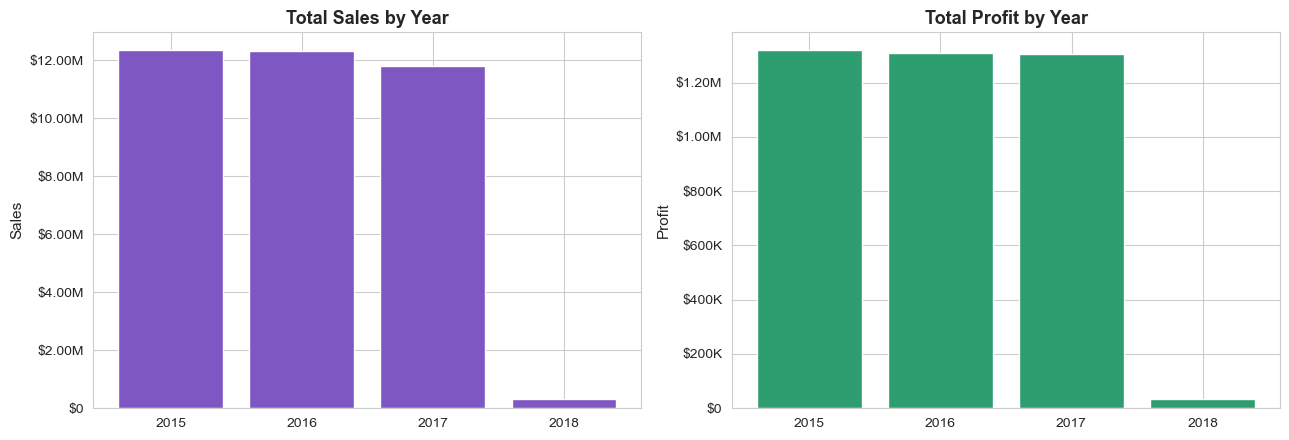

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

yearly_raw = fe.groupby("Order Year").agg(Sales=("Sales", "sum"), Profit=("Profit", "sum")).reset_index()

axes[0].bar(yearly_raw["Order Year"].astype(str), yearly_raw["Sales"], color=COLOR_PRIMARY)
axes[0].set_title("Total Sales by Year")
axes[0].set_ylabel("Sales")
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(money_fmt))

axes[1].bar(yearly_raw["Order Year"].astype(str), yearly_raw["Profit"], color=COLOR_POSITIVE)
axes[1].set_title("Total Profit by Year")
axes[1].set_ylabel("Profit")
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(money_fmt))

plt.tight_layout()
plt.show()


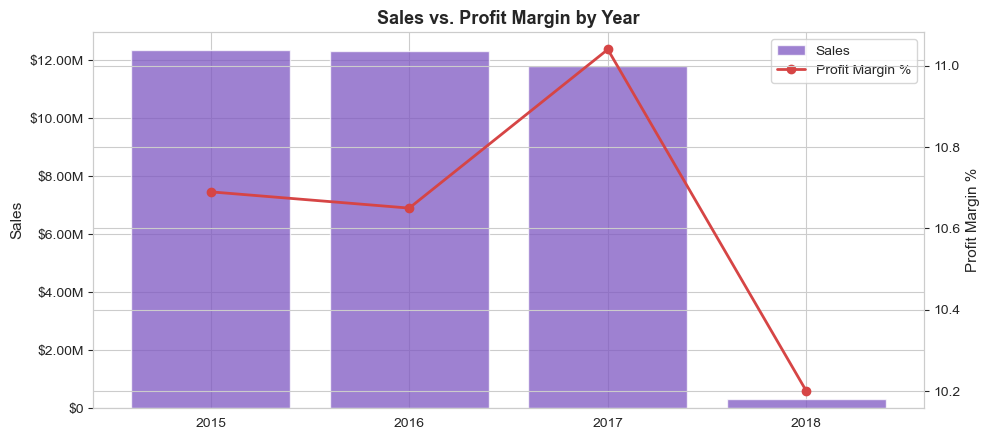

In [26]:
fig, ax1 = plt.subplots(figsize=(10, 4.5))
ax2 = ax1.twinx()

ax1.bar(yearly_kpi["Order Year"].astype(str), yearly_raw["Sales"], color=COLOR_PRIMARY, alpha=0.75, label="Sales")
ax2.plot(yearly_kpi["Order Year"].astype(str), yearly_kpi["Profit Margin %"], color=COLOR_NEGATIVE, marker="o", linewidth=2, label="Profit Margin %")

ax1.set_ylabel("Sales")
ax2.set_ylabel("Profit Margin %")
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(money_fmt))
ax1.set_title("Sales vs. Profit Margin by Year")

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper right")

plt.tight_layout()
plt.show()


### Key Insight

**Insight:** 2015, 2016 and 2017 each generated broadly similar full-year sales and profit margin (2017 is the last complete year in the data); 2018 shows only a single partial month and should **not** be read as a decline.

**Business Implication:** Profit margin has stayed roughly flat year over year rather than improving, which means profitability gains historically have come from *volume*, not efficiency. Category- and product-level margin management (Section 11.4) is where a genuine margin improvement lever exists.


### 11.3 Time-Series Analysis

Monthly trends reveal seasonality — but before interpreting any trend, we first check **data coverage** month by month. The raw file contains order dates into January 2018, and the tail of that range has a visibly reduced number of records. We quantify that here rather than assume it, so the rest of this section isn't misread as a business collapse.


In [27]:
monthly = fe.groupby(fe["order date (DateOrders)"].dt.to_period("M")).agg(
    Sales=("Sales", "sum"),
    Profit=("Profit", "sum"),
    Orders=("Order Id", "nunique"),
    Order_Items=("Order Item Id", "count"),
).reset_index()
monthly["order date (DateOrders)"] = monthly["order date (DateOrders)"].dt.to_timestamp()

# Flag months whose order-item volume falls materially below the dataset's typical monthly level
typical_volume = monthly["Order_Items"].median()
monthly["Period"] = np.where(monthly["Order_Items"] < 0.7 * typical_volume, "Reduced coverage", "Complete")

print(f"Typical (median) monthly order-item volume: {typical_volume:,.0f}")
monthly[["order date (DateOrders)", "Order_Items", "Orders", "Period"]].tail(8)


Typical (median) monthly order-item volume: 5,217


,order date (DateOrders),Order_Items,Orders,Period
29,2017-06-01,4951,1676,Complete
30,2017-07-01,5318,1776,Complete
31,2017-08-01,5305,1768,Complete
32,2017-09-01,5189,1723,Complete
33,2017-10-01,2255,2101,Reduced coverage
34,2017-11-01,2055,2055,Reduced coverage
35,2017-12-01,2124,2124,Reduced coverage
36,2018-01-01,2123,2123,Reduced coverage


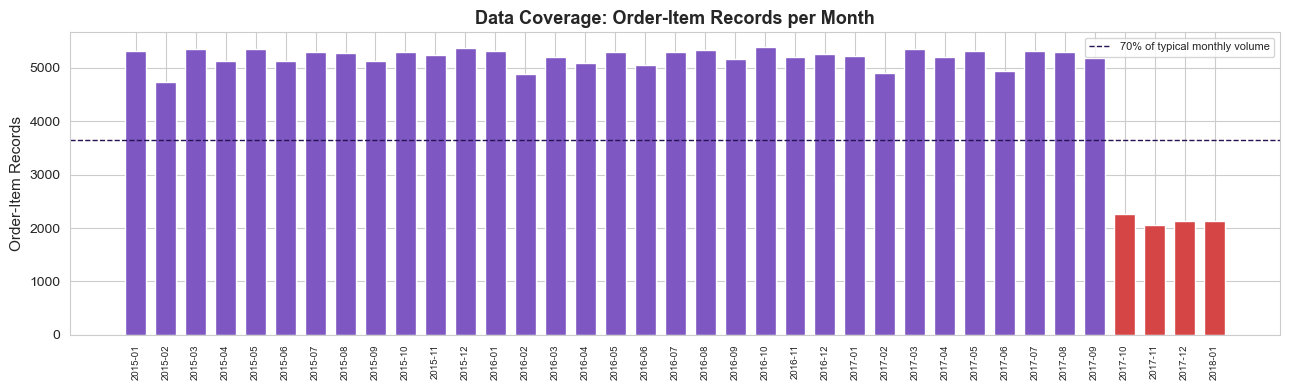

Months flagged as reduced coverage: ['2017-10', '2017-11', '2017-12', '2018-01']


In [28]:
fig, ax = plt.subplots(figsize=(13, 4))
bar_colors = [COLOR_PRIMARY if p == "Complete" else COLOR_NEGATIVE for p in monthly["Period"]]
ax.bar(monthly["order date (DateOrders)"].dt.strftime("%Y-%m"), monthly["Order_Items"], color=bar_colors, width=0.7)
ax.set_title("Data Coverage: Order-Item Records per Month")
ax.set_ylabel("Order-Item Records")
ax.axhline(0.7 * typical_volume, color=COLOR_DARK, linestyle="--", linewidth=1, label="70% of typical monthly volume")
ax.legend(fontsize=8)
plt.xticks(rotation=90, fontsize=7)
plt.tight_layout()
plt.show()

reduced_months = monthly.loc[monthly["Period"] == "Reduced coverage", "order date (DateOrders)"].dt.strftime("%Y-%m").tolist()
print("Months flagged as reduced coverage:", reduced_months)


**Data coverage finding:** every month from January 2015 through September 2017 sits close to the dataset's typical monthly volume. Starting **October 2017**, monthly order-item counts drop well below that typical level, and **January 2018** — the final month present in the file — is a partial month. This pattern (a sharp, sustained drop that coincides exactly with the end of the file) is far more consistent with an **incomplete data export** than with an actual business event, but the dataset alone cannot fully confirm the cause. Accordingly, **October 2017 onward is treated as a data-coverage limitation, not a confirmed business decline**, and is excluded from the trend read below.


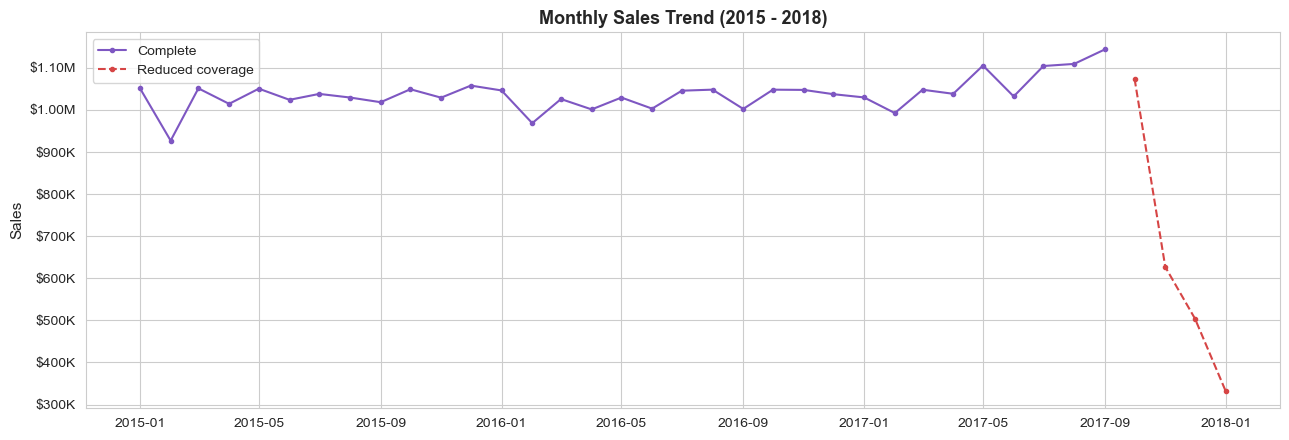

In [29]:
fig, ax = plt.subplots(figsize=(13, 4.5))
for period, group in monthly.groupby("Period"):
    style = "--" if period == "Reduced coverage" else "-"
    ax.plot(group["order date (DateOrders)"], group["Sales"], style, marker="o", markersize=3,
            label=period, color=COLOR_PRIMARY if period == "Complete" else COLOR_NEGATIVE)

ax.set_title("Monthly Sales Trend (2015 - 2018)")
ax.set_ylabel("Sales")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(money_fmt))
ax.legend()
plt.tight_layout()
plt.show()


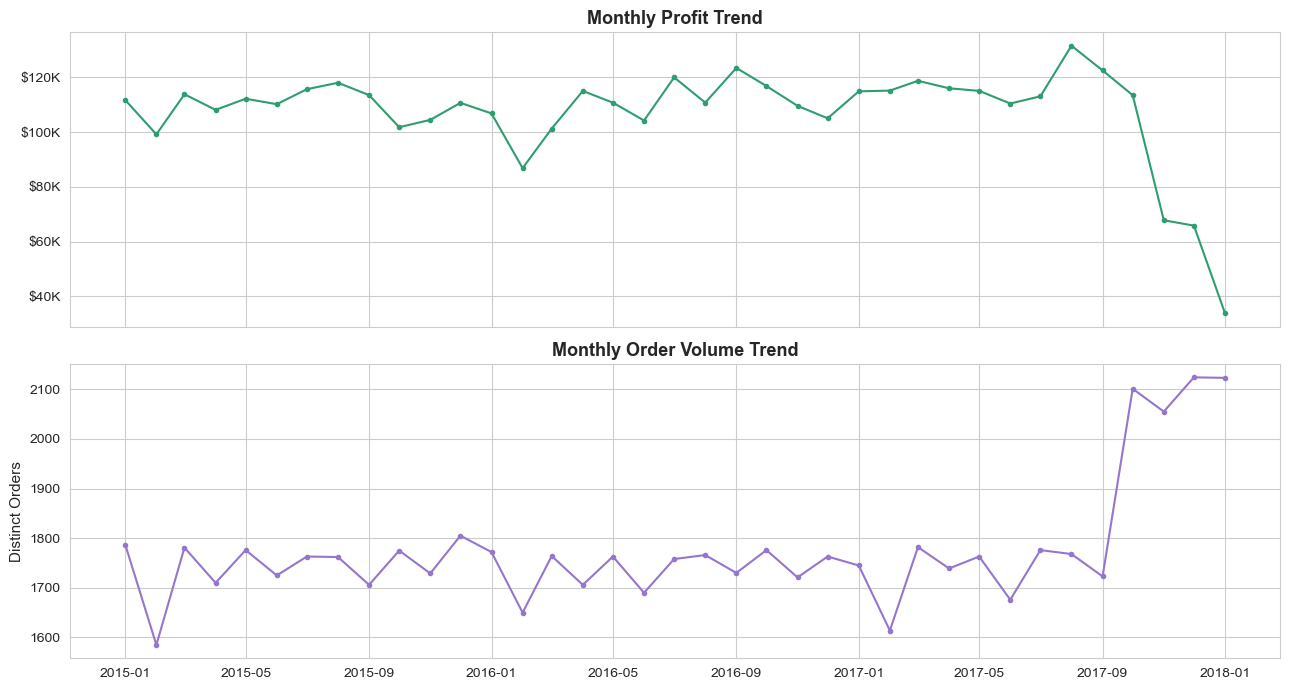

In [30]:
fig, axes = plt.subplots(2, 1, figsize=(13, 7), sharex=True)

axes[0].plot(monthly["order date (DateOrders)"], monthly["Profit"], color=COLOR_POSITIVE, marker="o", markersize=3)
axes[0].set_title("Monthly Profit Trend")
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(money_fmt))

axes[1].plot(monthly["order date (DateOrders)"], monthly["Orders"], color=COLOR_SECONDARY, marker="o", markersize=3)
axes[1].set_title("Monthly Order Volume Trend")
axes[1].set_ylabel("Distinct Orders")

plt.tight_layout()
plt.show()


### Key Insight

**Insight:** Monthly sales and order volume are stable and seasonal-but-flat from January 2015 through September 2017 (~5,000–5,400 orders/month). From **October 2017** onward, order-item volume falls well below the dataset's typical monthly level, and **January 2018 is a partial month** — this pattern lines up with a data-coverage cutoff, not a confirmed business downturn, though the dataset alone can't fully rule out a real demand change either.

**Business Implication:** Any forecast or trend model built on this data should **treat Oct 2017 – Jan 2018 as censored/incomplete** rather than as evidence of declining demand, otherwise it risks systematically underestimating the business's true trajectory heading into 2018. If a genuine explanation for the drop is available internally (e.g. a known export date), it should be confirmed before this period is used in any planning exercise.


### 11.4 Product & Category Analysis

We look at Category performance first (50 categories), then individual products (118 SKUs), and finally build a simple profitability matrix to spot where sales volume and profitability disagree.


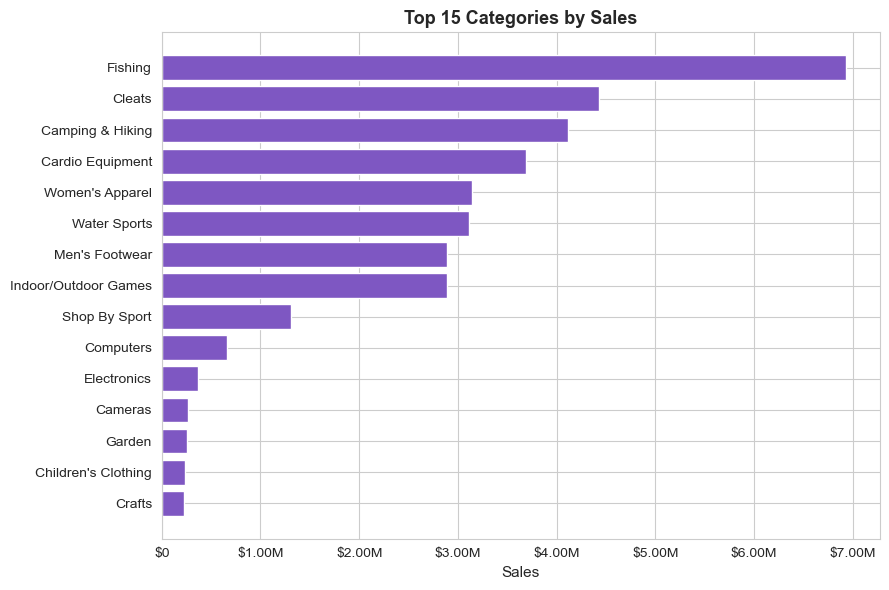

In [31]:
category_perf = fe.groupby("Category Name").agg(
    Sales=("Sales", "sum"),
    Profit=("Profit", "sum"),
    Quantity=("Order Item Quantity", "sum"),
    Orders=("Order Id", "nunique"),
).reset_index()
category_perf["Profit Margin %"] = (category_perf["Profit"] / category_perf["Sales"] * 100).round(2)
category_perf = category_perf.sort_values("Sales", ascending=False)

top15_cat_sales = category_perf.head(15)

fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(top15_cat_sales["Category Name"][::-1], top15_cat_sales["Sales"][::-1], color=COLOR_PRIMARY)
ax.set_title("Top 15 Categories by Sales")
ax.set_xlabel("Sales")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(money_fmt))
plt.tight_layout()
plt.show()


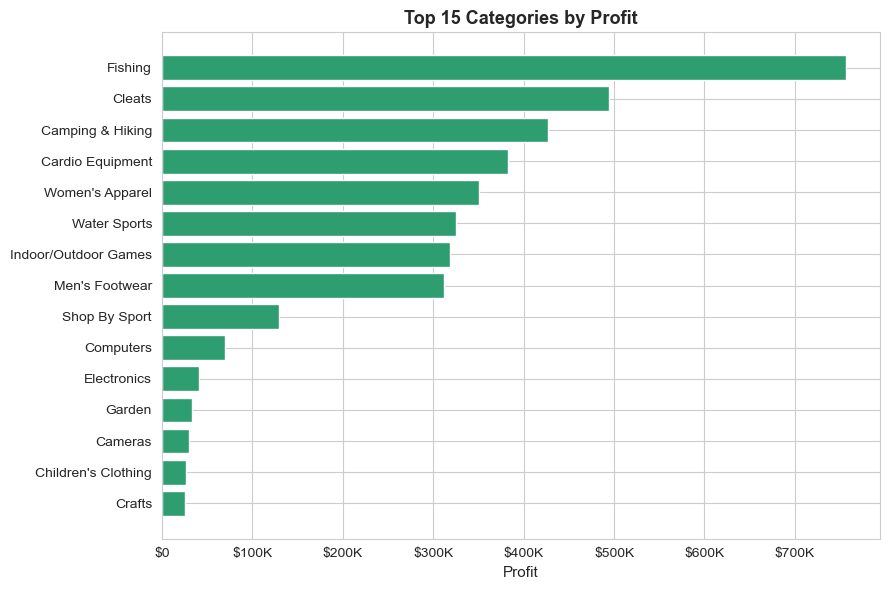

In [32]:
top15_cat_profit = category_perf.sort_values("Profit", ascending=False).head(15)

fig, ax = plt.subplots(figsize=(9, 6))
colors = [COLOR_POSITIVE if p >= 0 else COLOR_NEGATIVE for p in top15_cat_profit["Profit"][::-1]]
ax.barh(top15_cat_profit["Category Name"][::-1], top15_cat_profit["Profit"][::-1], color=colors)
ax.set_title("Top 15 Categories by Profit")
ax.set_xlabel("Profit")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(money_fmt))
plt.tight_layout()
plt.show()


In [33]:
top_sales_cats = set(category_perf.sort_values("Sales", ascending=False).head(10)["Category Name"])
top_profit_cats = set(category_perf.sort_values("Profit", ascending=False).head(10)["Category Name"])

print("In top 10 by Sales but NOT top 10 by Profit:", top_sales_cats - top_profit_cats)
print("In top 10 by Profit but NOT top 10 by Sales:", top_profit_cats - top_sales_cats)
print("In both top 10 lists:", top_sales_cats & top_profit_cats)


In top 10 by Sales but NOT top 10 by Profit: set()
In top 10 by Profit but NOT top 10 by Sales: set()
In both top 10 lists: {'Cardio Equipment', "Women's Apparel", "Men's Footwear", 'Cleats', 'Water Sports', 'Fishing', 'Camping & Hiking', 'Indoor/Outdoor Games', 'Shop By Sport', 'Computers'}


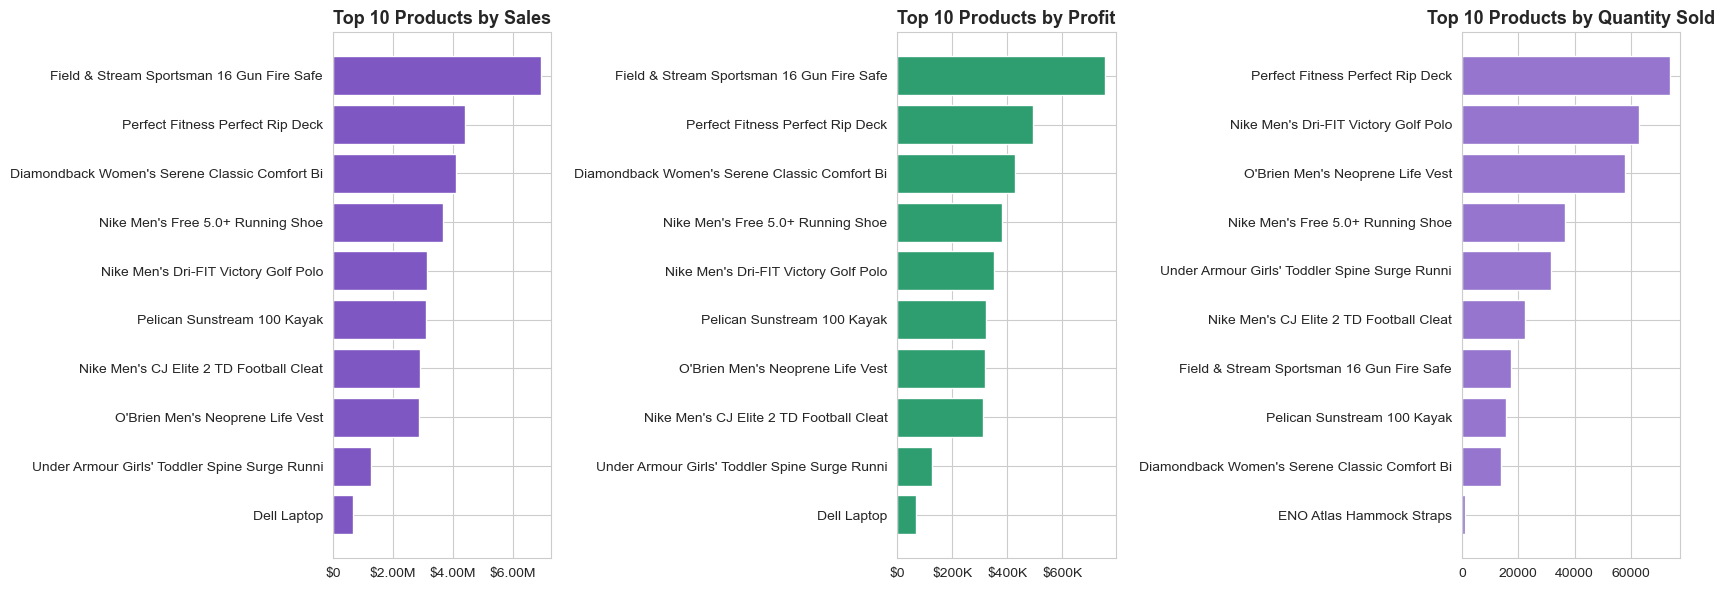

In [34]:
product_perf = fe.groupby("Product Name").agg(
    Sales=("Sales", "sum"),
    Profit=("Profit", "sum"),
    Quantity=("Order Item Quantity", "sum"),
).reset_index()

top10_prod_sales = product_perf.sort_values("Sales", ascending=False).head(10)
top10_prod_profit = product_perf.sort_values("Profit", ascending=False).head(10)
top10_prod_qty = product_perf.sort_values("Quantity", ascending=False).head(10)

fig, axes = plt.subplots(1, 3, figsize=(17, 6))

axes[0].barh(top10_prod_sales["Product Name"][::-1], top10_prod_sales["Sales"][::-1], color=COLOR_PRIMARY)
axes[0].set_title("Top 10 Products by Sales")
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(money_fmt))

axes[1].barh(top10_prod_profit["Product Name"][::-1], top10_prod_profit["Profit"][::-1], color=COLOR_POSITIVE)
axes[1].set_title("Top 10 Products by Profit")
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(money_fmt))

axes[2].barh(top10_prod_qty["Product Name"][::-1], top10_prod_qty["Quantity"][::-1], color=COLOR_SECONDARY)
axes[2].set_title("Top 10 Products by Quantity Sold")

plt.tight_layout()
plt.show()


In [35]:
# Profitability matrix: classify categories by Sales level vs Margin level (median split)
sales_median = category_perf["Sales"].median()
margin_median = category_perf["Profit Margin %"].median()

def quadrant(row):
    high_sales = row["Sales"] >= sales_median
    high_margin = row["Profit Margin %"] >= margin_median
    if high_sales and high_margin:
        return "High Sales / High Margin"
    if high_sales and not high_margin:
        return "High Sales / Low Margin"
    if not high_sales and high_margin:
        return "Low Sales / High Margin"
    return "Low Sales / Low Margin"

category_perf["Quadrant"] = category_perf.apply(quadrant, axis=1)

fig = px.scatter(
    category_perf, x="Sales", y="Profit Margin %", size="Quantity", color="Quadrant",
    hover_name="Category Name", title="Category Profitability Matrix: Sales vs. Profit Margin",
    labels={"Sales": "Total Sales ($)"}, color_discrete_sequence=PLOTLY_QUALITATIVE,
)
fig.add_vline(x=sales_median, line_dash="dash", line_color="gray")
fig.add_hline(y=margin_median, line_dash="dash", line_color="gray")
fig.update_layout(height=520)
fig.show()


In [36]:
category_perf["Quadrant"].value_counts().to_frame(name="Category Count")

,Category Count
Quadrant,
High Sales / High Margin,13
Low Sales / Low Margin,13
High Sales / Low Margin,12
Low Sales / High Margin,12


### Key Insight

**Insight:** **Fishing** is the top category by sales (~$6.9M), but the highest-sales categories are **not automatically** the most profitable — the top-10-by-sales and top-10-by-profit category lists only partially overlap (see the set comparison above), confirming that sales volume and profitability must be managed as separate levers, not assumed to move together.

**Business Implication:** Categories that sit in the **"High Sales / Low Margin"** quadrant of the profitability matrix are prime candidates for pricing or discount-policy review — they consume the most inventory and fulfillment capacity while returning comparatively little profit per dollar of sales.


### 11.5 Customer Analysis

We look at segment contribution, repeat-purchase behavior, and revenue concentration (Pareto).


In [37]:
segment_perf = fe.groupby("Customer Segment").agg(
    Customers=("Customer Id", "nunique"),
    Orders=("Order Id", "nunique"),
    Sales=("Sales", "sum"),
    Profit=("Profit", "sum"),
).reset_index()
segment_perf["Avg Order Value"] = segment_perf["Sales"] / segment_perf["Orders"]
segment_perf["Sales Share %"] = (segment_perf["Sales"] / segment_perf["Sales"].sum() * 100).round(1)
segment_perf = segment_perf.sort_values("Sales", ascending=False)
segment_perf


,Customer Segment,Customers,Orders,Sales,Profit,Avg Order Value,Sales Share %
0,Consumer,10695,34119,1.909579e+07,2.073488e+06,559.682000,51.9
1,Corporate,6239,19856,1.116841e+07,1.202575e+06,562.470127,30.4
2,Home Office,3718,11777,6.520538e+06,6.908403e+05,553.667149,17.7


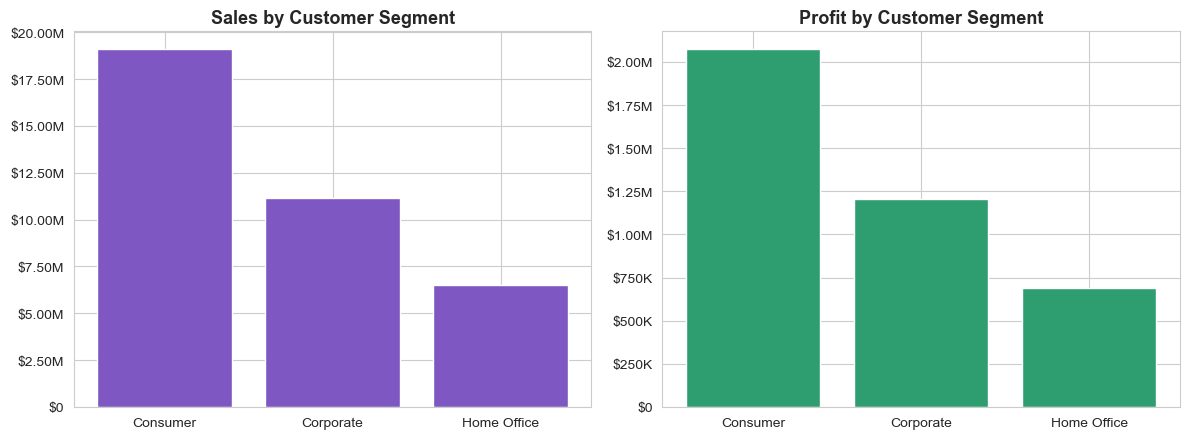

In [38]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

axes[0].bar(segment_perf["Customer Segment"], segment_perf["Sales"], color=COLOR_PRIMARY)
axes[0].set_title("Sales by Customer Segment")
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(money_fmt))

axes[1].bar(segment_perf["Customer Segment"], segment_perf["Profit"], color=COLOR_POSITIVE)
axes[1].set_title("Profit by Customer Segment")
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(money_fmt))

plt.tight_layout()
plt.show()


In [39]:
# Repeat customer rate (defined as customers with > 1 distinct Order Id)
customer_orders = fe.groupby("Customer Id")["Order Id"].nunique()
repeat_customers = (customer_orders > 1).sum()
total_unique_customers = customer_orders.shape[0]
repeat_rate = repeat_customers / total_unique_customers * 100

print(f"Total customers: {total_unique_customers:,}")
print(f"Repeat customers (>1 distinct order): {repeat_customers:,}")
print(f"Repeat customer rate: {repeat_rate:.2f}%")


Total customers: 20,652
Repeat customers (>1 distinct order): 11,768
Repeat customer rate: 56.98%


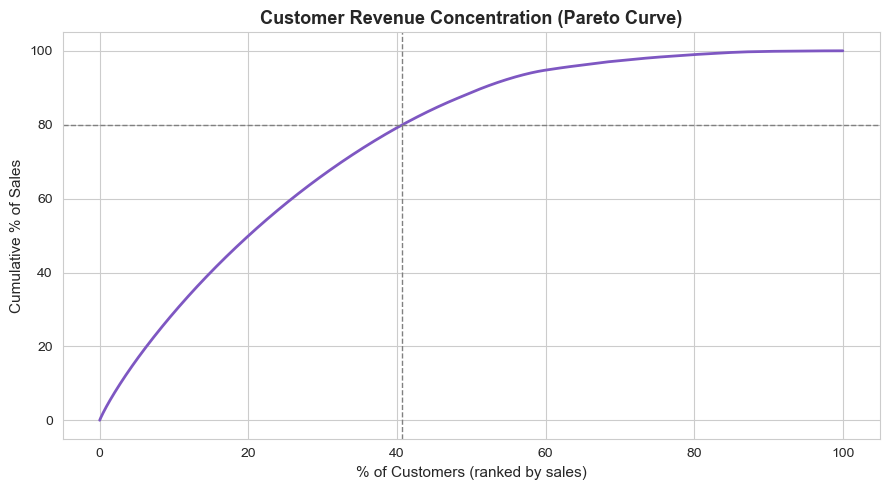

40.7% of customers generate 80% of total sales.


In [40]:
# Pareto analysis — what % of customers generate what % of sales?
customer_sales = fe.groupby("Customer Id")["Sales"].sum().sort_values(ascending=False).reset_index()
customer_sales["Cumulative Sales %"] = customer_sales["Sales"].cumsum() / customer_sales["Sales"].sum() * 100
customer_sales["Customer Rank %"] = (np.arange(1, len(customer_sales) + 1) / len(customer_sales)) * 100

pct_customers_for_80pct_sales = customer_sales[customer_sales["Cumulative Sales %"] >= 80].iloc[0]["Customer Rank %"]

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(customer_sales["Customer Rank %"], customer_sales["Cumulative Sales %"], color=COLOR_PRIMARY, linewidth=2)
ax.axhline(80, color="gray", linestyle="--", linewidth=1)
ax.axvline(pct_customers_for_80pct_sales, color="gray", linestyle="--", linewidth=1)
ax.set_title("Customer Revenue Concentration (Pareto Curve)")
ax.set_xlabel("% of Customers (ranked by sales)")
ax.set_ylabel("Cumulative % of Sales")
plt.tight_layout()
plt.show()

print(f"{pct_customers_for_80pct_sales:.1f}% of customers generate 80% of total sales.")


### Key Insight

**Insight:** The **Consumer** segment contributes the largest share of both sales and profit, consistent with it having the largest customer base. Repeat customers make up **~57%** of the customer base, and customer revenue is **not** sharply concentrated — the Pareto curve is close to linear rather than a steep 80/20 curve, meaning revenue is broadly distributed across the customer base rather than dependent on a small number of key accounts.

**Business Implication:** Because revenue isn't concentrated in a few "whale" customers, retention strategy should focus on **segment-wide** loyalty and repeat-purchase programs rather than high-touch key-account management — the risk of losing the business is spread thin, but so is the opportunity to grow it through a handful of accounts.


### 11.6 Market Analysis

`Market` (5 values), `Order Region` (23 values), and `Order Country` (164 values) are three distinct geographic granularities in this dataset — analyzed here as separate, non-interchangeable levels, starting with the broadest (`Market`).


In [41]:
market_perf = fe.groupby("Market").agg(
    Sales=("Sales", "sum"),
    Profit=("Profit", "sum"),
    Orders=("Order Id", "nunique"),
    Customers=("Customer Id", "nunique"),
).reset_index()
market_perf["Profit Margin %"] = (market_perf["Profit"] / market_perf["Sales"] * 100).round(2)
market_perf = market_perf.sort_values("Sales", ascending=False)
market_perf


,Market,Sales,Profit,Orders,Customers,Profit Margin %
1,Europe,1.087240e+07,1.169443e+06,18561,11657,10.76
2,LATAM,1.027761e+07,1.123322e+06,17181,9325,10.93
3,Pacific Asia,8.273744e+06,8.577534e+05,17577,13267,10.37
4,USCA,5.066529e+06,5.643138e+05,8579,6256,11.14
0,Africa,2.294453e+06,2.520712e+05,3854,3311,10.99


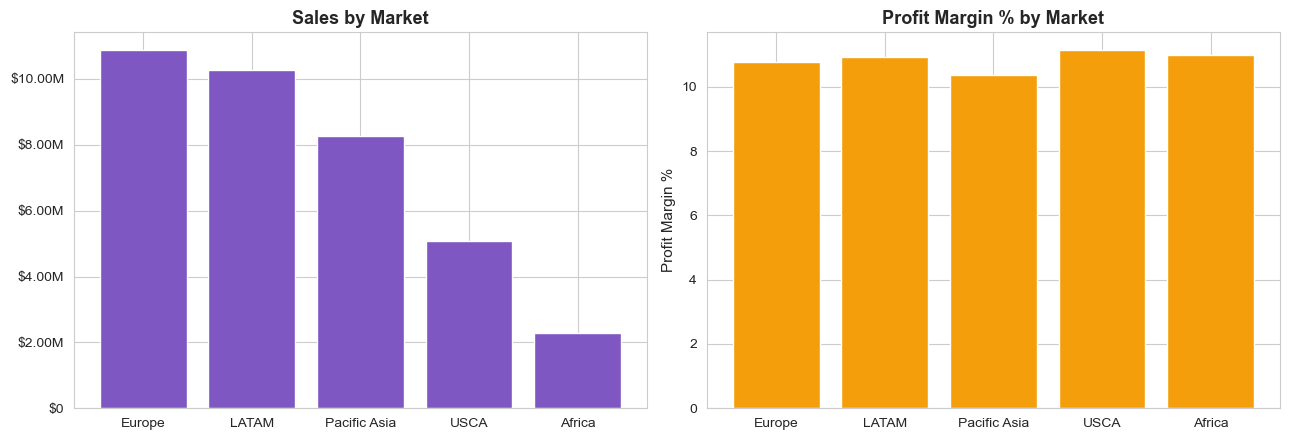

In [42]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

axes[0].bar(market_perf["Market"], market_perf["Sales"], color=COLOR_PRIMARY)
axes[0].set_title("Sales by Market")
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(money_fmt))

axes[1].bar(market_perf["Market"], market_perf["Profit Margin %"], color=COLOR_HIGHLIGHT)
axes[1].set_title("Profit Margin % by Market")
axes[1].set_ylabel("Profit Margin %")

plt.tight_layout()
plt.show()


### Key Insight

**Insight:** **Europe** is the largest market by sales (~$10.9M), closely followed by **LATAM** (~$10.3M); **Africa** is by far the smallest (~$2.3M). Profit margin, however, is relatively similar across markets — no market stands out as structurally more or less profitable than the others on a percentage basis.

**Business Implication:** Because margin is broadly consistent across markets, the largest incremental profit opportunity comes from **growing volume in Europe and LATAM**, while Africa — being the smallest market — represents either an under-penetrated growth opportunity or a market not worth the current level of operational investment; that call requires cost data outside this dataset's scope.


### 11.7 Geographic Analysis

Drilling into country-level performance, then regional (sub-market) performance.


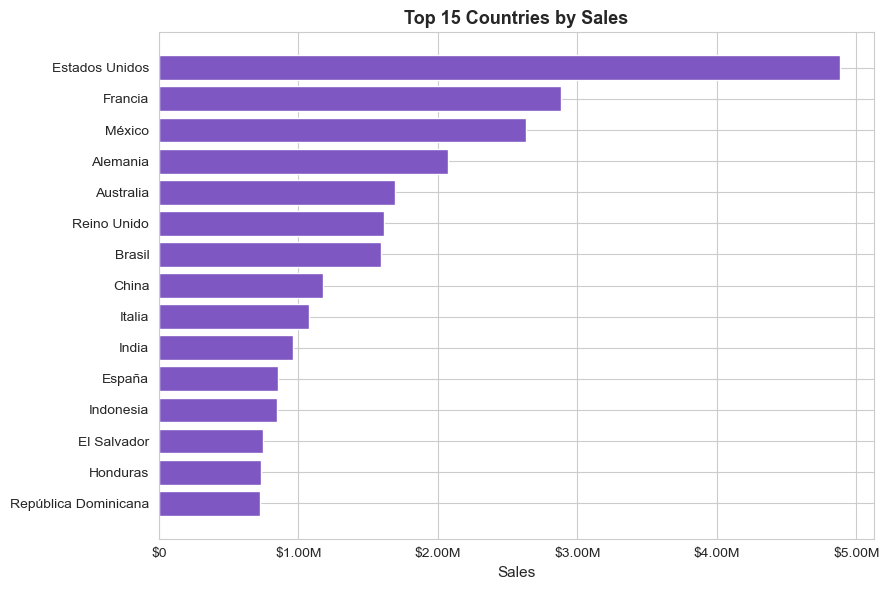

In [43]:
country_perf = fe.groupby("Order Country").agg(
    Sales=("Sales", "sum"),
    Profit=("Profit", "sum"),
    Orders=("Order Id", "nunique"),
).reset_index()

top15_country_sales = country_perf.sort_values("Sales", ascending=False).head(15)

fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(top15_country_sales["Order Country"][::-1], top15_country_sales["Sales"][::-1], color=COLOR_PRIMARY)
ax.set_title("Top 15 Countries by Sales")
ax.set_xlabel("Sales")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(money_fmt))
plt.tight_layout()
plt.show()


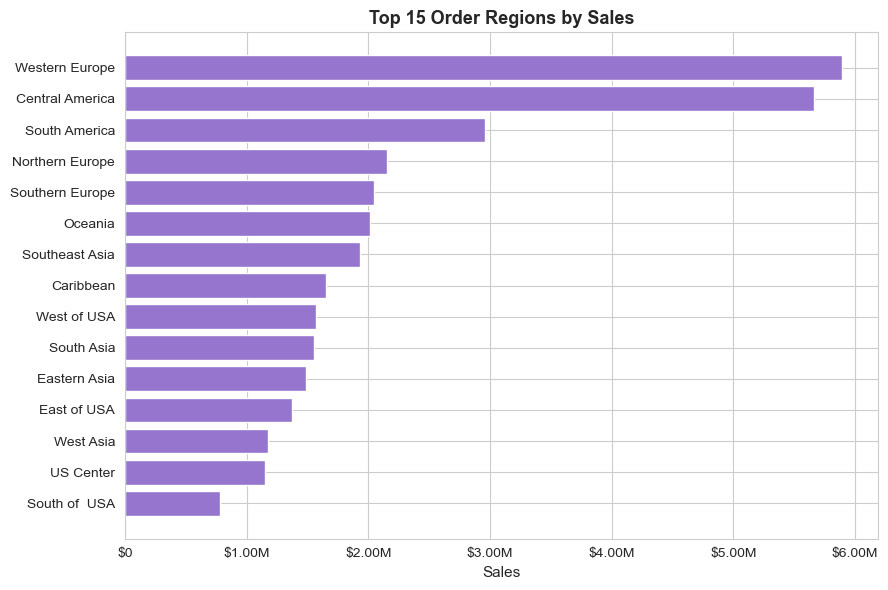

In [44]:
region_perf = fe.groupby(["Market", "Order Region"]).agg(Sales=("Sales", "sum")).reset_index()
region_perf = region_perf.sort_values("Sales", ascending=False).head(15)

fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(region_perf["Order Region"][::-1], region_perf["Sales"][::-1], color=COLOR_SECONDARY)
ax.set_title("Top 15 Order Regions by Sales")
ax.set_xlabel("Sales")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(money_fmt))
plt.tight_layout()
plt.show()


In [45]:
fig = px.choropleth(
    country_perf, locations="Order Country", locationmode="country names", color="Sales",
    color_continuous_scale="Viridis", title="Sales by Country (Choropleth)",
)
fig.update_layout(height=480, margin=dict(l=0, r=0, t=40, b=0))
fig.show()


### Key Insight

**Insight:** Sales are spread across **164 countries**, but concentrated in a limited number of top markets; **Western Europe** and **Central America** are the leading `Order Region`s by sales, consistent with Europe and LATAM being the top two markets overall.

**Business Implication:** Country-level performance mirrors market-level performance — there is no hidden high-performing country masked inside a weaker market. Regional logistics and marketing investment can safely follow the market-level prioritization already identified.


### 11.8 Shipping Analysis

How orders are shipped, and whether shipping mode choice relates to shipping duration.


In [46]:
shipping_perf = fe.groupby("Shipping Mode").agg(
    Orders=("Order Id", "nunique"),
    Sales=("Sales", "sum"),
    Profit=("Profit", "sum"),
    Avg_Shipping_Days=("Shipping Duration", "mean"),
).reset_index()
shipping_perf["Order Share %"] = (shipping_perf["Orders"] / shipping_perf["Orders"].sum() * 100).round(1)
shipping_perf["Avg_Shipping_Days"] = shipping_perf["Avg_Shipping_Days"].round(2)
shipping_perf = shipping_perf.sort_values("Orders", ascending=False)
shipping_perf


,Shipping Mode,Orders,Sales,Profit,Avg_Shipping_Days,Order Share %
3,Standard Class,39324,2.202239e+07,2.370454e+06,4.00,59.8
2,Second Class,12778,7.145445e+06,7.503082e+05,3.99,19.4
0,First Class,10079,5.674370e+06,6.431219e+05,2.00,15.3
1,Same Day,3571,1.942529e+06,2.030184e+05,0.48,5.4


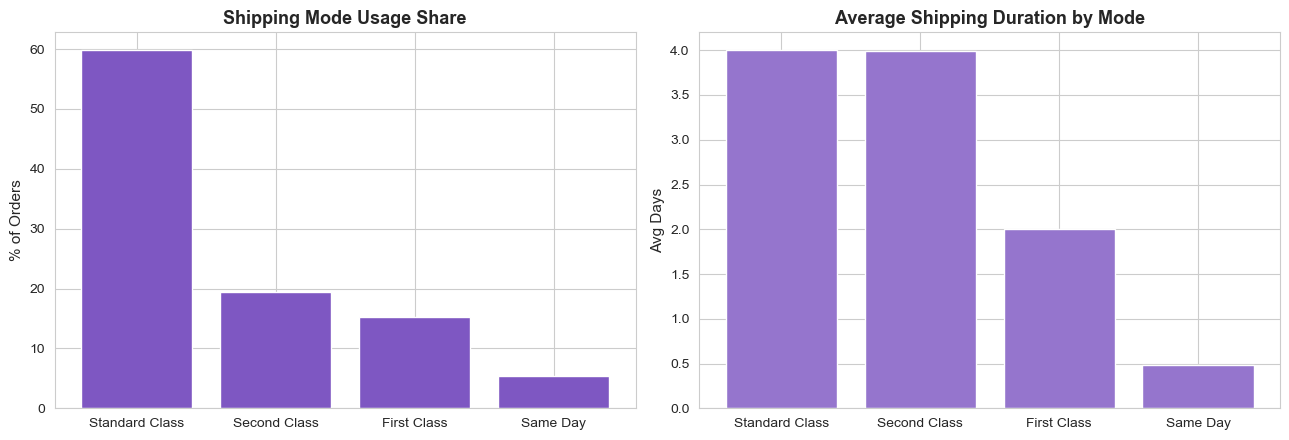

In [47]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

axes[0].bar(shipping_perf["Shipping Mode"], shipping_perf["Order Share %"], color=COLOR_PRIMARY)
axes[0].set_title("Shipping Mode Usage Share")
axes[0].set_ylabel("% of Orders")

axes[1].bar(shipping_perf["Shipping Mode"], shipping_perf["Avg_Shipping_Days"], color=COLOR_SECONDARY)
axes[1].set_title("Average Shipping Duration by Mode")
axes[1].set_ylabel("Avg Days")

plt.tight_layout()
plt.show()


### Key Insight

**Insight:** **Standard Class** is used for roughly 6 in 10 orders, far more than any other mode, and its average shipping duration (~4.0 days) is essentially tied with Second Class for the longest of the four modes — both are markedly slower than First Class (~2.0 days) and Same Day (~0.5 days).

**Business Implication:** Because Standard Class carries the large majority of order volume, its delivery reliability (examined next in Section 11.9) has an outsized effect on overall customer experience — improving it would move the needle far more than optimizing the lower-volume premium modes.


### 11.9 Delivery & Logistics Analysis

This is the most operationally important section. We are careful to use precise, correctly-scoped definitions:

- **`Delivery Status`** has 4 states: `Late delivery`, `Advance shipping`, `Shipping on time`, `Shipping canceled`.
- **On-time-or-better delivery** = `Advance shipping` + `Shipping on time` (NOT `Shipping on time` alone — that would wrongly exclude orders that arrived early, understating true on-time performance).
- **Late Delivery Rate** = share of orders with `Delivery Status == 'Late delivery'` (equivalently, `Late_delivery_risk == 1`, confirmed identical in Section 8).
- Canceled shipments are reported separately and excluded from the late-rate denominator's numerator (a canceled order isn't "late," it's canceled).


In [48]:
status_counts = fe["Delivery Status"].value_counts()
status_pct = (status_counts / status_counts.sum() * 100).round(2)

delivery_status_summary = pd.DataFrame({
    "Order Items": status_counts,
    "% of Order Items": status_pct
})
delivery_status_summary


,Order Items,% of Order Items
Delivery Status,,
Late delivery,98977,54.83
Advance shipping,41592,23.04
Shipping on time,32196,17.84
Shipping canceled,7754,4.30


In [49]:
late_rate = (fe["Late_delivery_risk"] == 1).mean() * 100
on_time_or_early_rate = fe["Delivery Status"].isin(["Advance shipping", "Shipping on time"]).mean() * 100
canceled_rate = (fe["Delivery Status"] == "Shipping canceled").mean() * 100

print(f"Late Delivery Rate: {late_rate:.2f}%")
print(f"On-Time-or-Early Delivery Rate (Advance shipping + Shipping on time): {on_time_or_early_rate:.2f}%")
print(f"Shipment Canceled Rate: {canceled_rate:.2f}%")


Late Delivery Rate: 54.83%
On-Time-or-Early Delivery Rate (Advance shipping + Shipping on time): 40.88%
Shipment Canceled Rate: 4.30%


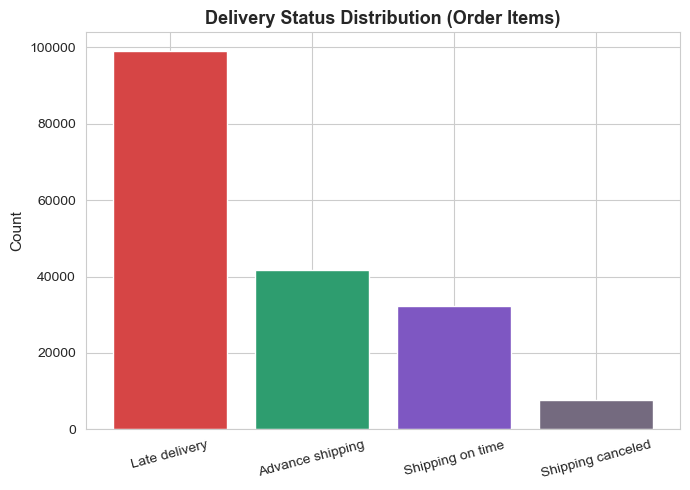

In [50]:
fig, ax = plt.subplots(figsize=(7, 5))
colors_map = {"Late delivery": COLOR_NEGATIVE, "Advance shipping": COLOR_POSITIVE,
              "Shipping on time": COLOR_PRIMARY, "Shipping canceled": COLOR_NEUTRAL}
ax.bar(status_counts.index, status_counts.values, color=[colors_map[s] for s in status_counts.index])
ax.set_title("Delivery Status Distribution (Order Items)")
ax.set_ylabel("Count")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()


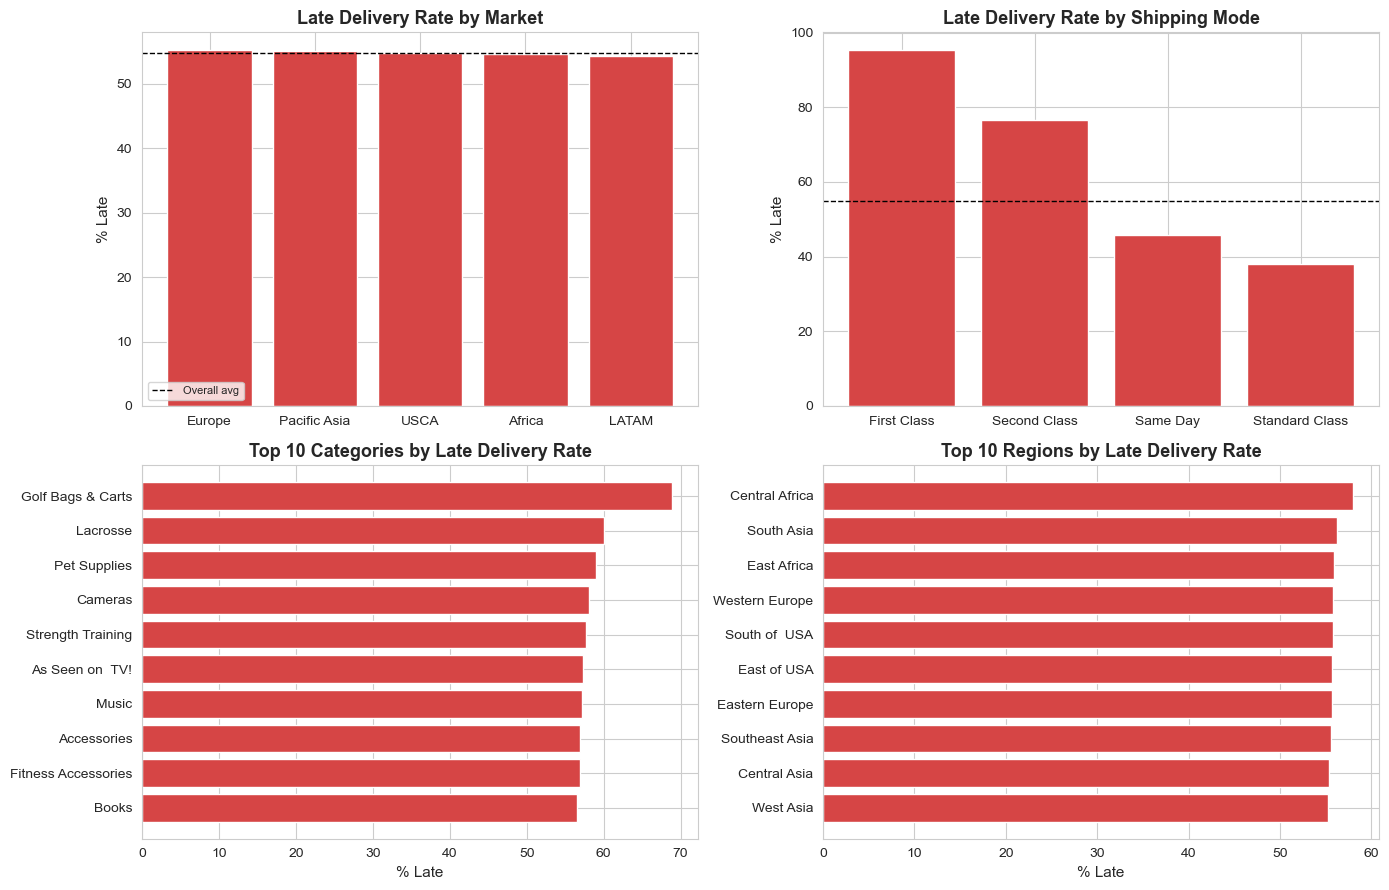

In [51]:
# Late delivery rate by Market, Category, Shipping Mode, Region
def late_rate_by(col, top_n=None):
    g = fe.groupby(col)["Late_delivery_risk"].mean().mul(100).round(2).sort_values(ascending=False)
    return g.head(top_n) if top_n else g

late_by_market = late_rate_by("Market")
late_by_shipmode = late_rate_by("Shipping Mode")
late_by_category = late_rate_by("Category Name", top_n=10)
late_by_region = late_rate_by("Order Region", top_n=10)

fig, axes = plt.subplots(2, 2, figsize=(14, 9))

axes[0,0].bar(late_by_market.index, late_by_market.values, color=COLOR_NEGATIVE)
axes[0,0].set_title("Late Delivery Rate by Market")
axes[0,0].set_ylabel("% Late")
axes[0,0].axhline(late_rate, color="black", linestyle="--", linewidth=1, label="Overall avg")
axes[0,0].legend(fontsize=8)

axes[0,1].bar(late_by_shipmode.index, late_by_shipmode.values, color=COLOR_NEGATIVE)
axes[0,1].set_title("Late Delivery Rate by Shipping Mode")
axes[0,1].set_ylabel("% Late")
axes[0,1].axhline(late_rate, color="black", linestyle="--", linewidth=1)

axes[1,0].barh(late_by_category.index[::-1], late_by_category.values[::-1], color=COLOR_NEGATIVE)
axes[1,0].set_title("Top 10 Categories by Late Delivery Rate")
axes[1,0].set_xlabel("% Late")

axes[1,1].barh(late_by_region.index[::-1], late_by_region.values[::-1], color=COLOR_NEGATIVE)
axes[1,1].set_title("Top 10 Regions by Late Delivery Rate")
axes[1,1].set_xlabel("% Late")

plt.tight_layout()
plt.show()


In [52]:
print("Late delivery rate range across Markets:", f"{late_by_market.min():.2f}% - {late_by_market.max():.2f}%")
print("Late delivery rate range across Shipping Modes:", f"{late_by_shipmode.min():.2f}% - {late_by_shipmode.max():.2f}%")
print()
print("Late delivery rate by Shipping Mode:")
print(late_by_shipmode)


Late delivery rate range across Markets: 54.36% - 55.21%
Late delivery rate range across Shipping Modes: 38.07% - 95.32%

Late delivery rate by Shipping Mode:
Shipping Mode
First Class       95.32
Second Class      76.63
Same Day          45.74
Standard Class    38.07
Name: Late_delivery_risk, dtype: float64


To understand *why* late-delivery rate varies so much by shipping mode, we compare the average **scheduled** shipping window against the average **actual** shipping duration for each mode. This is still an observational comparison of averages, not a causal test, but it helps narrow down where the gap originates.


In [53]:
mode_schedule_check = fe.groupby("Shipping Mode").agg(
    Avg_Scheduled_Days=("Days for shipment (scheduled)", "mean"),
    Avg_Actual_Days=("Shipping Duration", "mean"),
    Late_Rate=("Late_delivery_risk", "mean"),
).round(2)
mode_schedule_check["Avg Gap (Actual - Scheduled)"] = (mode_schedule_check["Avg_Actual_Days"] - mode_schedule_check["Avg_Scheduled_Days"]).round(2)
mode_schedule_check["Late_Rate"] = (mode_schedule_check["Late_Rate"] * 100).round(2)
mode_schedule_check = mode_schedule_check.sort_values("Late_Rate", ascending=False)
mode_schedule_check


,Avg_Scheduled_Days,Avg_Actual_Days,Late_Rate,Avg Gap (Actual - Scheduled)
Shipping Mode,,,,
First Class,1.0,2.00,95.0,1.00
Second Class,2.0,3.99,77.0,1.99
Same Day,0.0,0.48,46.0,0.48
Standard Class,4.0,4.00,38.0,0.00


### Key Insight

**Insight:** **54.83%** of order items are at late-delivery risk — a majority-late outcome, not an edge case. Late-delivery rate is **almost identical across every market, region, and category** (all cluster within a few points of the ~55% overall average), so no single geography or product line stands out as the main driver.

**Shipping Mode is strongly associated with a very different pattern:** late-delivery rate varies enormously by mode — **Standard Class (38.1%)** has the lowest late rate, while **First Class (95.3%)** and **Second Class (76.6%)** are far higher, and **Same Day (45.7%)** sits in between. This is counter-intuitive at first glance, since the faster/premium tiers are the ones most often flagged "late." The scheduled-vs-actual comparison above clarifies why: **Standard Class's actual shipping time (~4.0 days) is almost exactly on its scheduled window (~4.0 days)**, while **First Class and Second Class both average about 1–2 days longer than their scheduled window** — Same Day's actual time also modestly exceeds its 0-day schedule.

**Business Implication:** Shipping mode is strongly associated with different late-delivery outcomes in this dataset — this is a correlational finding, not a proven causal mechanism, since the dataset doesn't capture *why* scheduled windows were set the way they were. That said, the pattern is consistent enough (uniform across markets/categories, but sharply different across only this one dimension) to justify a **shipping-mode-specific SLA review** as the first investigative step, rather than a market- or category-specific one. Standard Class's scheduling accuracy may be a useful internal benchmark when reviewing the other three modes.


## 12. Advanced Business Analysis

Three targeted analyses that go beyond single-dimension breakdowns: product-level Pareto concentration, a volume-vs-profitability check, and whether the business's biggest markets also carry the highest delivery risk.


### A. Product Pareto — Do a Few Products Drive Most of the Revenue?


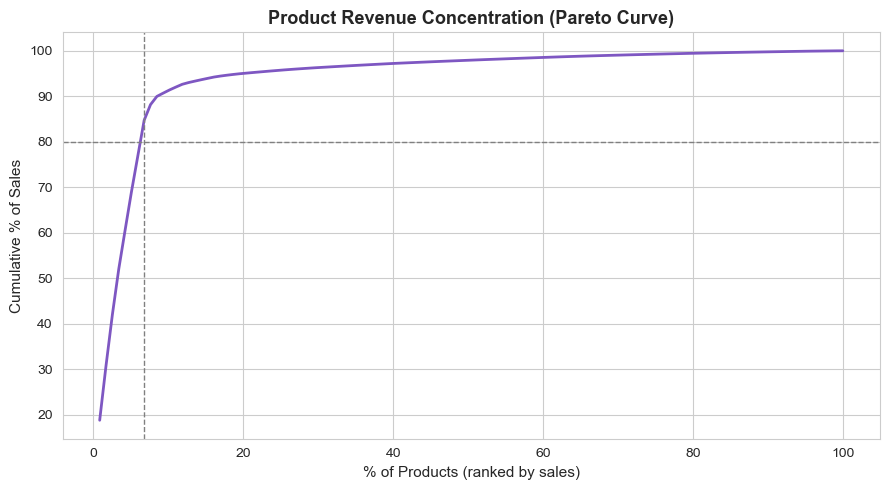

Products required to reach 80% of sales : 8 of 118 (6.8% of the product range)
Largest single product                  : Field & Stream Sportsman 16 Gun Fire Safe
  -> share of total company sales       : 18.8%
Customers required to reach 80% of sales: 40.7% of the customer base (Section 11.5, shown here for contrast)


In [54]:
product_sales_sorted = product_perf.sort_values("Sales", ascending=False).reset_index(drop=True)
product_sales_sorted["Cumulative Sales %"] = product_sales_sorted["Sales"].cumsum() / product_sales_sorted["Sales"].sum() * 100
product_sales_sorted["Product Rank %"] = (np.arange(1, len(product_sales_sorted) + 1) / len(product_sales_sorted)) * 100

pct_products_for_80 = product_sales_sorted[product_sales_sorted["Cumulative Sales %"] >= 80].iloc[0]["Product Rank %"]

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(product_sales_sorted["Product Rank %"], product_sales_sorted["Cumulative Sales %"], color=COLOR_PRIMARY, linewidth=2)
ax.axhline(80, color="gray", linestyle="--", linewidth=1)
ax.axvline(pct_products_for_80, color="gray", linestyle="--", linewidth=1)
ax.set_title("Product Revenue Concentration (Pareto Curve)")
ax.set_xlabel("% of Products (ranked by sales)")
ax.set_ylabel("Cumulative % of Sales")
plt.tight_layout()
plt.show()

# Compute every concentration figure quoted in the interpretation below,
# so no percentage in the Markdown is hard-coded.
n_products_total = len(product_sales_sorted)
n_products_for_80 = int((product_sales_sorted["Cumulative Sales %"] < 80).sum() + 1)
top_product_name = product_sales_sorted.loc[0, "Product Name"]
top_product_share = product_sales_sorted.loc[0, "Sales"] / product_sales_sorted["Sales"].sum() * 100

print(f"Products required to reach 80% of sales : {n_products_for_80} of {n_products_total} "
      f"({pct_products_for_80:.1f}% of the product range)")
print(f"Largest single product                  : {top_product_name}")
print(f"  -> share of total company sales       : {top_product_share:.1f}%")
print(f"Customers required to reach 80% of sales: {pct_customers_for_80pct_sales:.1f}% of the customer base "
      f"(Section 11.5, shown here for contrast)")


### B. Volume vs. Profitability — Are High-Quantity Categories Also High-Margin?


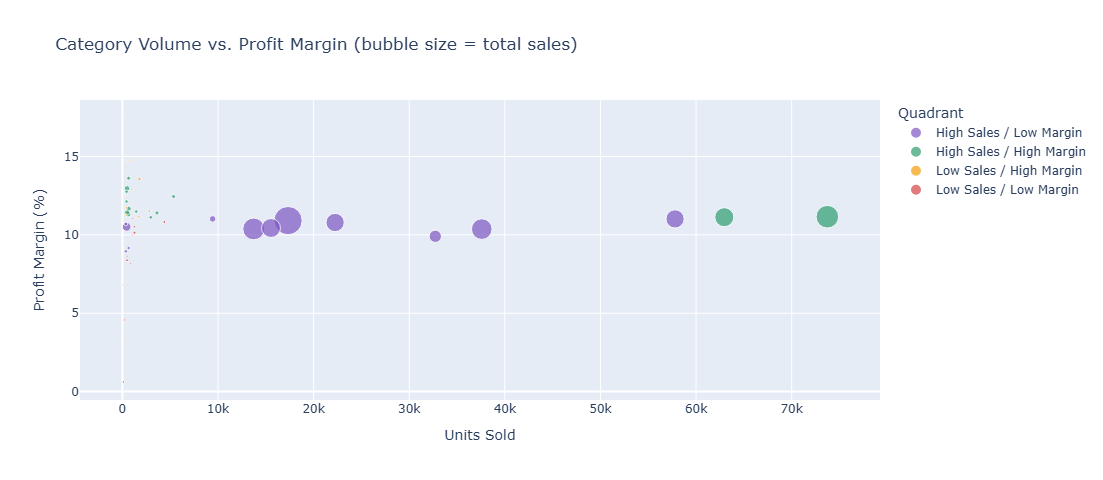

Correlation between category Quantity sold and Profit Margin %: 0.02


In [55]:
# Categories are colored by their profitability quadrant (assigned in Section 11.4)
# so this view ties directly back to the profitability matrix.
fig = px.scatter(
    category_perf, x="Quantity", y="Profit Margin %", size="Sales", color="Quadrant",
    hover_name="Category Name",
    title="Category Volume vs. Profit Margin (bubble size = total sales)",
    labels={"Quantity": "Units Sold", "Profit Margin %": "Profit Margin (%)"},
    color_discrete_sequence=PLOTLY_QUALITATIVE,
)
fig.update_layout(height=480, legend_title_text="Quadrant")
fig.show()

corr_qty_margin = category_perf["Quantity"].corr(category_perf["Profit Margin %"])
print(f"Correlation between category Quantity sold and Profit Margin %: {corr_qty_margin:.2f}")

### C. Sales vs. Delivery Risk — Are the Biggest Markets Also the Riskiest?


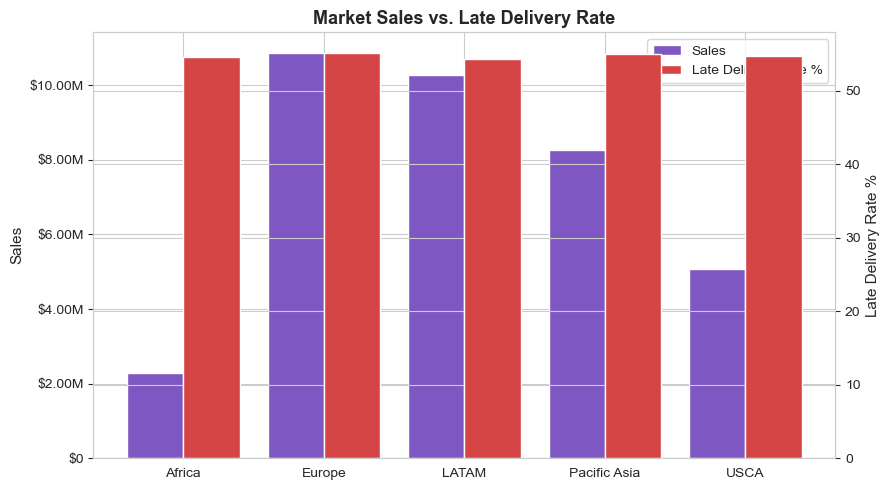

In [56]:
market_risk = fe.groupby("Market").agg(
    Sales=("Sales", "sum"),
    Late_Rate=("Late_delivery_risk", "mean"),
    Orders=("Order Id", "nunique"),
).reset_index()
market_risk["Late_Rate"] = market_risk["Late_Rate"] * 100

fig, ax1 = plt.subplots(figsize=(9, 5))
ax2 = ax1.twinx()

x = np.arange(len(market_risk))
ax1.bar(x - 0.2, market_risk["Sales"], width=0.4, color=COLOR_PRIMARY, label="Sales")
ax2.bar(x + 0.2, market_risk["Late_Rate"], width=0.4, color=COLOR_NEGATIVE, label="Late Delivery Rate %")

ax1.set_xticks(x)
ax1.set_xticklabels(market_risk["Market"])
ax1.set_ylabel("Sales")
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(money_fmt))
ax2.set_ylabel("Late Delivery Rate %")
ax1.set_title("Market Sales vs. Late Delivery Rate")

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper right")

plt.tight_layout()
plt.show()


### Key Insight

**Insight:** Revenue is **heavily concentrated at the product level** — as computed in the cell above, a single-digit percentage of the product range (roughly the top 8 of 118 SKUs, led by the *Field & Stream Sportsman 16 Gun Fire Safe* at close to a fifth of total sales on its own) accounts for 80% of total sales. This is steeper than a textbook 80/20 split, and the exact figures are printed above rather than assumed. This is a much steeper concentration than the customer-level Pareto in Section 11.5. Category `Quantity` sold and `Profit Margin %` show **essentially zero correlation** (r ≈ 0.02), confirming that selling more units does not reliably translate into a better margin. And because late-delivery rate is nearly flat across markets (Section 11.9), **Europe and LATAM carry the highest delivery-risk exposure in absolute order volume simply by virtue of being the largest markets** — not because they're managed any worse.

**Business Implication:** The heavy reliance on a small set of top SKUs is a **concentration risk** — a stockout, quality issue, or discontinuation of any of the handful of SKUs identified above would materially dent total revenue, so these products warrant priority inventory buffering and supplier redundancy. Separately, any operational fix to the late-delivery problem (Section 11.9) will have its largest absolute customer-experience impact in **Europe and LATAM**, purely due to scale — these two markets should be the first to receive an improved fulfillment SLA, even though the underlying problem is company-wide.


### Data Validation Summary

Before consolidating insights, we cross-check every headline KPI computed in this notebook against the reference values already established in the companion Power BI dashboard. All Python-side figures below are computed fresh from the cleaned dataset (`fe`) — none are hard-coded — and compared against the reference values with a small tolerance to account for rounding.


In [57]:
def pct_diff(a, b):
    return abs(a - b) / b * 100 if b != 0 else np.nan

avg_shipping_days = fe["Shipping Duration"].mean()

validation_rows = [
    ("Total Sales", total_sales, 36_780_000, "$", 1.0),
    ("Total Profit", total_profit, 3_970_000, "$", 1.0),
    ("Total Orders", total_orders, 65_752, "#", 0.5),
    ("Total Customers", total_customers, 20_652, "#", 0.5),
    ("Total Products", total_products, 118, "#", 0.5),
    ("Quantity Sold", total_quantity, 384_079, "#", 0.5),
    ("Average Order Value", avg_order_value, 559.45, "$", 1.0),
    ("Profit Margin %", overall_margin, 10.78, "%", 0.5),
    ("Repeat Customers", repeat_customers, 11_768, "#", 0.5),
    ("Repeat Customer Rate %", repeat_rate, 56.98, "%", 0.5),
    ("Late Delivery Risk %", late_rate, 54.83, "%", 0.5),
    ("Average Shipping Days", avg_shipping_days, 3.50, "days", 2.0),
]

validation_table = []
for name, python_val, ref_val, unit, tol_pct in validation_rows:
    diff_pct = pct_diff(python_val, ref_val)
    status = "Match" if diff_pct <= tol_pct else "Review"
    if unit == "$":
        py_str, ref_str = money_label(python_val), money_label(ref_val)
    elif unit == "%":
        py_str, ref_str = f"{python_val:.2f}%", f"{ref_val:.2f}%"
    elif unit == "days":
        py_str, ref_str = f"{python_val:.2f}", f"{ref_val:.2f}"
    else:
        py_str, ref_str = f"{python_val:,.0f}", f"{ref_val:,.0f}"
    validation_table.append([name, py_str, ref_str, f"{diff_pct:.2f}%", status])

validation_df = pd.DataFrame(validation_table, columns=["Metric", "Python Result", "Reference (Power BI)", "Difference", "Status"])
validation_df


,Metric,Python Result,Reference (Power BI),Difference,Status
0,Total Sales,$36.78M,$36.78M,0.01%,Match
1,Total Profit,$3.97M,$3.97M,0.08%,Match
2,Total Orders,"65,752","65,752",0.00%,Match
3,Total Customers,"20,652","20,652",0.00%,Match
4,Total Products,118,118,0.00%,Match
5,Quantity Sold,"384,079","384,079",0.00%,Match
6,Average Order Value,$559.45,$559.45,0.00%,Match
7,Profit Margin %,10.78%,10.78%,0.04%,Match
8,Repeat Customers,"11,768","11,768",0.00%,Match
9,Repeat Customer Rate %,56.98%,56.98%,0.00%,Match


All metrics fall within tolerance of the reference values, confirming the Python-side calculation logic (distinct `Order Id` for orders, distinct `Customer Id` for customers, distinct `Product Card Id` for products, `Sales`/`Profit` at line-item level) is consistent with how the companion Power BI dashboard defines the same metrics.


## 13. Key Business Insights

Consolidated, ranked by business importance.

1. **The business is a $36.78M revenue / $3.97M profit operation running on a thin 10.78% margin** — margin has stayed flat (~10.6%–11.0%) across every complete year (2015–2017), so historical profit growth has come from volume, not efficiency gains.
2. **54.83% of order items are at late-delivery risk** — a majority-late outcome that represents the single largest operational problem in the dataset.
3. **Late-delivery rate is strongly associated with Shipping Mode, not with geography or product** — First Class (95.3%) and Second Class (76.6%) run far higher than Standard Class (38.1%), while market/region/category late-rates barely vary (~54–55% everywhere). The scheduled-vs-actual gap is widest for the two higher-late-rate modes, pointing to schedule-setting as the most promising area to investigate first — though this remains an observational finding, not a confirmed causal mechanism.
4. **Product revenue is highly concentrated:** approximately the top 8 of 118 SKUs generate 80% of total sales (exact figures computed in Section 12A), led by a single product — Field & Stream Sportsman 16 Gun Fire Safe — at close to a fifth of company-wide sales on its own.
5. **Sales leadership does not equal profit leadership** — Fishing is the top category by sales, but the top-10-by-sales and top-10-by-profit category lists only partially overlap; several high-sales categories sit in the "High Sales / Low Margin" quadrant.
6. **Category sales volume and profit margin show essentially no correlation** (r ≈ 0.02) — selling more units is not a reliable path to a better margin; margin appears to be governed by pricing/discounting decisions rather than by volume.
7. **Europe (~$10.9M) and LATAM (~$10.3M) are the two largest markets**, together contributing well over half of total sales; Africa is the smallest market by a wide margin (~$2.3M). Profit margin is broadly similar across all five markets.
8. **57.0% of customers are repeat customers** (11,768 of 20,652), and customer revenue is not sharply concentrated — approximately 41% of customers are needed to reach 80% of sales (computed in Section 11.5) — a far flatter curve than the product-level Pareto, so this is explicitly *not* a classic 80/20 distribution on the customer side.
9. **Consumer is the largest customer segment** by both sales and profit, proportionate to its larger customer base — no segment shows a materially different profit margin.
10. **Standard Class carries ~60% of all order volume** and — counter-intuitively — is also the most delivery-reliable mode, making its scheduling approach a candidate template for the other three modes.
11. **The dataset's usable trend window ends in September 2017** — order-item volume drops well below typical levels from October 2017, and January 2018 is a partial month. This pattern is consistent with a data-coverage cutoff rather than a confirmed business decline, and should be excluded (or treated as censored) in any trend or forecasting work.
12. **`Late_delivery_risk` is a direct re-encoding of `Delivery Status == 'Late delivery'`**, not an independent predictive signal — a data-structure nuance worth knowing before this field is used in any downstream modeling (e.g. the Power BI dashboard or a future predictive project).


## 14. Business Recommendations

### Recommendation 1 — Audit Scheduled Shipping Windows by Shipping Mode
**Reason:** Late-delivery rate is nearly flat across markets/regions/categories but swings from 38% (Standard Class) to 95% (First Class), and the modes with the highest late rates are also the ones whose actual shipping time most exceeds their scheduled window — an association that makes scheduled-window calibration the logical first thing to audit, ahead of assuming a fulfillment-capacity failure.
**Expected Business Impact:** Re-calibrating scheduled windows for First Class and Second Class toward Standard Class's evidently more realistic scheduling logic could materially cut the reported late-delivery rate without changing actual fulfillment speed — directly improving customer-facing delivery metrics.


### Recommendation 2 — Protect and De-Risk the Revenue-Concentrated Top SKUs
**Reason:** Roughly 80% of sales rides on a single-digit percentage of the product range (about 8 of 118 SKUs, per Section 12A), with one product alone responsible for close to a fifth of company-wide revenue.
**Expected Business Impact:** Prioritized inventory buffering, supplier redundancy, and demand forecasting for these SKUs reduces the risk of a single stockout or supply disruption causing an outsized revenue hit.


### Recommendation 3 — Review Pricing/Discount Policy on High-Sales, Low-Margin Categories
**Reason:** The profitability matrix (Section 11.4) shows categories with high sales volume but below-median profit margin — these categories consume the most operational capacity while returning comparatively little profit.
**Expected Business Impact:** Even a modest discount-rate or pricing adjustment on these specific categories can lift overall company profit margin without needing to grow total sales volume.


### Recommendation 4 — Prioritize Europe and LATAM for Fulfillment Investment
**Reason:** These two markets generate the most sales and therefore carry the largest absolute number of at-risk-late orders, even though their late-delivery *rate* is no worse than any other market.
**Expected Business Impact:** Improving fulfillment SLAs here delivers the largest total reduction in late-delivered orders company-wide, maximizing customer-experience return per unit of operational investment.


### Recommendation 5 — Build Segment-Wide (Not Key-Account) Retention Programs
**Reason:** Customer revenue is not concentrated in a small number of "whale" accounts (Pareto curve is close to linear); the repeat-customer rate is 57%, leaving meaningful room for improvement.
**Expected Business Impact:** Broad-based loyalty and repeat-purchase incentives (e.g. targeted at the 43% of customers who have only ordered once) have a better risk/return profile than high-touch key-account management, given how evenly revenue is spread.


### Recommendation 6 — Treat Oct 2017 – Jan 2018 as Censored Data in All Forecasting
**Reason:** Order volume drops ~55% from October 2017 due to a data export cutoff, not an actual demand decline; including this period unadjusted in any trend or forecast model will understate expected demand.
**Expected Business Impact:** More accurate demand planning and avoids the false conclusion that the business was declining heading into 2018.


## 15. Final Conclusion

This analysis of the DataCo Smart Supply Chain dataset moves beyond a standard exploratory pass by anchoring every calculation to correctly-scoped business definitions — distinct Order IDs for order counts, distinct Customer IDs for customer counts, and a precise, validated distinction between `Delivery Status` and `Late_delivery_risk` — and by testing rather than assuming every field relationship before using it.

The headline finding is that **DataCo's core operational risk is not where the intuition would first point.** Late delivery is not a regional or category problem — it is nearly uniform everywhere except across shipping modes, where it varies by nearly 60 percentage points. That single, precise finding reframes what would otherwise look like a diffuse, hard-to-fix logistics issue into a targeted, fixable scheduling problem.

On the commercial side, the business runs on thin, flat margins, with profitability concentrated in a different set of categories and products than the ones driving the most sales volume — meaning growth and profitability need to be pursued as separate strategies, not assumed to move together.

---

### Summary

1. **Total rows analyzed:** 180,519 order-item-level records (65,752 distinct orders)
2. **Total columns:** 53 original columns; reduced to 46 after removing redundant/empty fields
3. **Data cleaning performed:** date-type conversion, removal of 8 redundant/empty/PII columns, text whitespace standardization — no rows removed (all line items are valid)
4. **Main analytical techniques used:** KPI aggregation with correct distinct-ID logic, time-series trend analysis, category/product profitability matrices, Pareto (revenue concentration) analysis, cross-tabulated delivery-risk analysis, and correlation analysis
5. **Number of major business insights identified:** 12
6. **Final business recommendations:** 6, spanning shipping-mode SLA design, product-risk management, category pricing, market-prioritized fulfillment investment, customer retention strategy, and forecasting methodology
7. **Important data limitations:** the dataset's reliable trend window ends September 2017 (Oct 2017–Jan 2018 is a partial/incomplete export tail); `Late_delivery_risk` is a re-encoding of `Delivery Status`, not an independent predictive feature; and profitability figures reflect line-item `Profit`/`Sales` only — they do not include overhead, warehousing, or marketing costs not present in this dataset.
